# Хакатон: предиктор задержек городского транспорта — EDA для ML-части

> **Условие (из README).** Прогнозная точка — пара `(tr_id, T)`. На момент `T`
> известна вся телеметрия ТС до `T`. Нужно предсказать **фактическую задержку
> в секундах** (факт − план) на первой остановке, плановое прибытие на которую
> попадает в окно `(T+10 мин, T+15 мин]`. Метрика — MAE, из неё считается
> `score = (mae_zero − MAE) / (mae_zero − MAE_TARGET)`, обрезанный до [0, 1].
> Бейзлайн «прогноз = `cur_dev_s`» даёт ≈ 0.40. **Правило честности:** только
> данные с `event_time ≤ T` и подсказка `cur_dev_s`.

Что делаем в этом ноутбуке:

1. Разбираемся, **как устроена раздача**: какие файлы с чем связаны, что в них
   совпадает и где лежат ловушки (одинаковые файлы, синтетические клоны,
   утечка фактов).
2. Считаем статистику и строим те же графики, что в Задании 1 — raincloud,
   pairgrid, heatmap корреляций, Upset пропусков и совпадений, — плюс графики,
   нужные именно этой задаче (нитка графика, карта, автокорреляция задержки).
3. Строим **честные признаки на момент T**. Главное здесь — восстановить
   фактические прибытия на прошлые остановки **из GPS**, потому что для
   validate фактов в расписании нет.
4. Проверяем базовые модели по двум схемам валидации и пишем черновой сабмит.
5. Делаем выводы для архитектуры ML-модуля.

## Импорты и настройка

Всё то же, что в Задании 1, плюс `catboost` — он обязателен по стеку хакатона
(Python 3.12+, PyTorch, CatBoost, Docker).

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import ptitprince as pt
import upsetplot
from scipy import stats as spstats
from catboost import CatBoostRegressor

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

DATA = Path(os.environ.get("DATASET_DIR", "../../dataset"))  # корень датасета репозитория
RNG_SEED = 42

## [0] Загрузка данных

Всё время храним в pandas `datetime`. Если модели нужно число, переводим время
в Unix-секунды (`to_sec`), и дальше арифметика идёт в секундах.

In [2]:
def to_sec(s):
    return s.values.astype("datetime64[s]").astype(np.int64)

def read_traffic(split):
    return pd.read_csv(DATA / split / "traffic.csv", parse_dates=["event_time"], low_memory=False)

def read_schedule(path):
    s = pd.read_csv(path, parse_dates=["time_begin"] + (["time_fact_begin"] if "fact" in open(path, encoding="utf-8").readline() else []))
    xy = s["geom"].str.extract(r"POINT \(([-\d.]+) ([-\d.]+)\)").astype(float)
    s["stop_lon"], s["stop_lat"] = xy[0], xy[1]
    if "time_fact_begin" in s:
        s["delay_s"] = (s["time_fact_begin"] - s["time_begin"]).dt.total_seconds()
    return s

def read_points(path):
    return pd.read_csv(path, parse_dates=["T", "target_time_begin"])

traffic = {sp: read_traffic(sp) for sp in ["train", "test", "validate"]}
sched = {
    "train": read_schedule(DATA / "train" / "schedule.csv"),
    "test": read_schedule(DATA / "test" / "schedule.csv"),
    "validate": read_schedule(DATA / "validate" / "schedule_plan.csv"),
}
points = {
    "train": read_points(DATA / "labels" / "labels_train.csv"),
    "test": read_points(DATA / "labels" / "labels_test.csv"),
    "validate": read_points(DATA / "validate" / "points.csv"),
}
sample_sub = pd.read_csv(DATA / "sample_submission.csv", sep=";")

overview = pd.DataFrame([
    dict(split=sp, telemetry_rows=len(traffic[sp]), telemetry_tr=traffic[sp].tr_id.nunique(),
         schedule_rows=len(sched[sp]), schedule_tr=sched[sp].tr_id.nunique(),
         points=len(points[sp]), points_tr=points[sp].tr_id.nunique(),
         has_fact="time_fact_begin" in sched[sp], has_target="target_delay_s" in points[sp])
    for sp in ["train", "test", "validate"]])
overview

,split,telemetry_rows,telemetry_tr,schedule_rows,schedule_tr,points,points_tr,has_fact,has_target
0,train,287849,56,16674,39,4434,39,True,True
1,test,105945,30,5558,13,353,13,True,True
2,validate,105945,30,5558,13,151,11,False,False


## [A] Как устроена раздача: связи и ловушки

Прежде чем что-то обучать, проверим, **что с чем совпадает**. От этого
зависит, как правильно валидироваться и чего нельзя делать.

In [3]:
REAL_TR = sorted(set(sched["test"].tr_id))
checks = {}
checks["test/traffic.csv == validate/traffic.csv (побайтно)"] = (
    (DATA / "test" / "traffic.csv").read_bytes() == (DATA / "validate" / "traffic.csv").read_bytes())
checks["остановки validate == остановки test"] = set(sched["validate"].tt_action_item_id) == set(sched["test"].tt_action_item_id)
checks["реальные ТС test целиком входят в train"] = set(REAL_TR) <= set(sched["train"].tr_id)
tt = sched["test"].merge(sched["train"], on="tt_action_item_id", suffixes=("_te", "_tr"))
checks["факты test == факты train по тем же остановкам"] = bool(
    ((tt.time_fact_begin_te - tt.time_fact_begin_tr).dt.total_seconds().abs() < 2).all())
checks["даты расписания"] = ", ".join(sorted(sched["train"].order_date.astype(str).unique()))
checks["ТС validate ⊂ ТС test"] = set(points["validate"].tr_id) <= set(points["test"].tr_id)
checks["sample_id validate ∩ train/test"] = int(points["validate"].sample_id.isin(
    pd.concat([points["train"].sample_id, points["test"].sample_id])).sum())
pd.Series(checks, name="результат").to_frame()

,результат
test/traffic.csv == validate/traffic.csv (побайтно),True
остановки validate == остановки test,True
реальные ТС test целиком входят в train,True
факты test == факты train по тем же остановкам,True
даты расписания,2026-01-06
ТС validate ⊂ ТС test,True
sample_id validate ∩ train/test,0


Синтетические ТС в train имеют id `9000000+`. Проверим, что каждый из них —
клон одного из 13 реальных ТС: та же последовательность остановок, но другие
задержки.

In [4]:
def stop_seq(s, tid):
    return tuple(s[s.tr_id == tid].sort_values("time_begin").tt_action_item_id)

str_ = sched["train"]
SYN_TR = sorted(set(str_.tr_id) - set(REAL_TR))
real_seqs = {t: stop_seq(str_, t) for t in REAL_TR}
addr_seq = lambda tid: tuple(str_[str_.tr_id == tid].sort_values("time_begin").building_address)
real_addr = {t: addr_seq(t) for t in REAL_TR}
clone_of = {}
for t in SYN_TR:
    a = addr_seq(t)
    clone_of[t] = next((r for r, ra in real_addr.items() if ra == a), None)
SOURCE = {**{t: t for t in REAL_TR}, **clone_of}  # ТС -> исходное реальное ТС

clone_tbl = pd.Series(clone_of).rename("клон реального ТС").to_frame()
clone_tbl["остановок"] = [len(addr_seq(t)) for t in clone_tbl.index]
print("синтетических ТС:", len(SYN_TR), "| у всех найден реальный прототип:", all(v is not None for v in clone_of.values()))
clone_tbl.groupby("клон реального ТС").size().rename("число клонов").to_frame().T

синтетических ТС: 26 | у всех найден реальный прототип: True


клон реального ТС,122048,122613,122658,129964,130072,130238,131672,132430,133300,133957,134040,134494,135081
число клонов,2,2,2,2,2,2,2,2,2,2,2,2,2


**Что из этого следует (важно для всей команды):**

1. **Весь датасет — это один день** (2026-01-06) и **13 реальных ТС**. Train,
   test и validate — не разные периоды, а **разные моменты `T` одного и того же
   дня у одних и тех же машин**, перемешанные через 5 минут. Train к тому же
   дополнен 26 синтетическими клонами (по 2 на каждое реальное ТС) с тем же
   маршрутом и зашумлёнными задержками.
2. `validate/traffic.csv` — **тот же файл**, что `test/traffic.csv`, а
   `validate/schedule_plan.csv` — это `test/schedule.csv` без столбца факта.
3. **Утечка:** в `train/schedule.csv` и `test/schedule.csv` лежит
   `time_fact_begin` для **всех** целевых остановок validate (проверка ниже).
   Если подставить эти факты, получится почти идеальный MAE. Но это прямое
   нарушение правила «только данные до T»: факт прибытия через 10–15 минут на
   момент T ещё неизвестен. **Мы это не используем.** Лучше написать
   организаторам: как минимум, чтобы жюри не удивлялось чужим «идеальным» скорам.
4. Из-за п.1 любая валидация «перемешанными строками» или даже «по ТС»
   **без учёта клонов** будет завышена: клоны — почти копии.

In [5]:
vp = points["validate"]
leak = vp.merge(sched["train"][["tt_action_item_id", "time_fact_begin"]],
                left_on="target_stop_id", right_on="tt_action_item_id", how="left")
print("доля validate-точек, для которых факт целевой остановки лежит в train/schedule.csv:",
      leak.time_fact_begin.notna().mean())
print("-> НЕ используем: это данные из будущего относительно T")

доля validate-точек, для которых факт целевой остановки лежит в train/schedule.csv: 1.0
-> НЕ используем: это данные из будущего относительно T


## [1.2] Статистика по датасету

Та же функция `describe_dataset`, что в Задании 1: размерность, типы, классы,
описательные статистики, NaN и нули по классам. «Класс» в каждой таблице свой:

- в разметке — `target_class` (early / ontime / late, пороги −60 с / +120 с);
- в расписании — `manual_fill` (факт заполнен вручную или автоматически);
- в телеметрии — `kind` (реальное ТС или синтетический клон).

In [6]:
def describe_dataset(df, features, class_col, name="dataset"):
    print(f"===== {name} =====")
    print(f"Размерность: {df.shape[0]} объектов x {df.shape[1]} признаков\n")
    print("Тип каждого признака:")
    display(df.dtypes.rename("dtype").to_frame().T)
    print(f"\nКлассы ({class_col}) и число объектов в каждом:")
    display(df[class_col].value_counts().sort_index().rename("n объектов").to_frame().T)
    print("\nОписательные статистики признаков:")
    display(df[features].describe().T.round(2))
    print("\nЧисло пропусков (NaN) по признакам и классам:")
    display(df.groupby(class_col)[features].apply(lambda g: g.isnull().sum()))
    print("\nЧисло объектов хотя бы с одним NaN, по классам:")
    display(df.groupby(class_col).apply(lambda g: g[features].isnull().any(axis=1).sum())
              .rename("n объектов с NaN").to_frame().T)
    print("\nЧисло значений, равных 0, по признакам и классам:")
    display(df.groupby(class_col)[features].apply(lambda g: (g == 0).sum()))

lab_tr = points["train"].copy()
lab_tr["lead_min"] = (lab_tr.target_time_begin - lab_tr["T"]).dt.total_seconds() / 60
lab_tr["kind"] = np.where(lab_tr.tr_id.isin(REAL_TR), "real", "synthetic")
describe_dataset(lab_tr, ["cur_dev_s", "target_delay_s", "lead_min"], "target_class", "labels_train")

===== labels_train =====
Размерность: 4434 объектов x 10 признаков

Тип каждого признака:


,sample_id,tr_id,T,target_stop_id,target_time_begin,cur_dev_s,target_delay_s,target_class,lead_min,kind
dtype,object,int64,datetime64[ns],int64,datetime64[ns],float64,float64,object,float64,object



Классы (target_class) и число объектов в каждом:


target_class,early,late,ontime
n объектов,679,998,2757



Описательные статистики признаков:


...

,cur_dev_s,target_delay_s,lead_min
target_class,,,
early,0,0,0
late,0,0,0
ontime,0,0,0



Число объектов хотя бы с одним NaN, по классам:


target_class,early,late,ontime
n объектов с NaN,0,0,0



Число значений, равных 0, по признакам и классам:


,cur_dev_s,target_delay_s,lead_min
target_class,,,
early,10,0,0
late,16,0,0
ontime,250,195,0


In [7]:
lab_te = points["test"].copy()
lab_te["lead_min"] = (lab_te.target_time_begin - lab_te["T"]).dt.total_seconds() / 60
describe_dataset(lab_te, ["cur_dev_s", "target_delay_s", "lead_min"], "target_class", "labels_test")

===== labels_test =====
Размерность: 353 объектов x 9 признаков

Тип каждого признака:


,sample_id,tr_id,T,target_stop_id,target_time_begin,cur_dev_s,target_delay_s,target_class,lead_min
dtype,object,int64,datetime64[ns],int64,datetime64[ns],float64,float64,object,float64



Классы (target_class) и число объектов в каждом:


target_class,early,late,ontime
n объектов,49,86,218



Описательные статистики признаков:


...

,cur_dev_s,target_delay_s,lead_min
target_class,,,
early,0,0,0
late,0,0,0
ontime,0,0,0



Число объектов хотя бы с одним NaN, по классам:


target_class,early,late,ontime
n объектов с NaN,0,0,0



Число значений, равных 0, по признакам и классам:


,cur_dev_s,target_delay_s,lead_min
target_class,,,
early,2,0,0
late,2,0,0
ontime,35,38,0


In [8]:
describe_dataset(sched["train"], ["delay_s", "stop_lon", "stop_lat"], "manual_fill", "train/schedule")

===== train/schedule =====
Размерность: 16674 объектов x 11 признаков

Тип каждого признака:


,tt_action_item_id,time_begin,time_fact_begin,order_date,manual_fill,tr_id,geom,building_address,stop_lon,stop_lat,delay_s
dtype,int64,datetime64[ns],datetime64[ns],object,bool,int64,object,object,float64,float64,float64



Классы (manual_fill) и число объектов в каждом:


manual_fill,False,True
n объектов,13704,2970



Описательные статистики признаков:


...

,delay_s,stop_lon,stop_lat
manual_fill,,,
False,0,0,0
True,0,0,0



Число объектов хотя бы с одним NaN, по классам:


manual_fill,False,True
n объектов с NaN,0,0



Число значений, равных 0, по признакам и классам:


,delay_s,stop_lon,stop_lat
manual_fill,,,
False,48,0,0
True,884,0,0


In [9]:
tr_tel = traffic["train"].copy()
tr_tel["kind"] = np.where(tr_tel.tr_id.isin(REAL_TR), "real", "synthetic")
TEL_NUM = ["lon", "lat", "alt", "speed", "heading"]
describe_dataset(tr_tel, TEL_NUM, "kind", "train/traffic")

===== train/traffic =====
Размерность: 287849 объектов x 15 признаков

Тип каждого признака:


,packet_id,tr_id,unit_id,event_time,device_event_id,location_valid,gps_time,lon,lat,alt,speed,heading,receive_time,is_hist_data,kind
dtype,object,int64,int64,datetime64[ns],int64,bool,object,float64,float64,float64,float64,float64,object,bool,object



Классы (kind) и число объектов в каждом:


kind,real,synthetic
n объектов,90952,196897



Описательные статистики признаков:


...

,lon,lat,alt,speed,heading
kind,,,,,
real,4976,4976,4976,4976,4976
synthetic,11523,11523,11523,11523,11523



Число объектов хотя бы с одним NaN, по классам:


kind,real,synthetic
n объектов с NaN,4976,11523



Число значений, равных 0, по признакам и классам:


,lon,lat,alt,speed,heading
kind,,,,,
real,1083,1083,15148,38274,16097
synthetic,3343,3343,32062,84596,34983


Что видно из таблиц:

- **Таргет небольшой:** медиана ≈ +24 с, IQR от −25 до +107 с, максимум ≈ 11 мин.
  Классы несбалансированы: ontime ≈ 62%, late ≈ 22%, early ≈ 15%.
- **Горизонт** (`lead_min`) почти всегда 10–12 минут, до 15 — редко: целевая
  остановка — *первая* в окне, а остановки идут часто.
- **`manual_fill=True`** (~18% остановок): у таких остановок задержка почти
  всегда 0 (медиана 0, в test даже IQR = 0). Похоже, это остановки, где факт
  не зафиксировался автоматически и был проставлен руками «по плану». Флаг есть
  и в `validate/schedule_plan.csv`, так что это **легальный и очень сильный
  признак** целевой остановки.
- **Телеметрия грязная:** ≈ 6% строк без координат/скорости, у части точек
  нулевые координаты (`lon = lat = 0`), встречаются `speed = 368` и
  `alt = 65505` (служебное «нет данных» в NDTP). Разберём ниже.

## [B] Качество телеметрии (NDTP)

Этот раздел нужен и нам, и бэкенду: те же фильтры придётся применять к живому
потоку эмулятора. Считаем доли аномалий и интервалы между пакетами.

,"train, %","test, %"
нет координат (NaN),5.73,6.18
location_valid=False,15.24,15.90
координаты = 0,1.54,2.13
speed > 120 км/ч,0.02,0.05
alt > 5000 (служебное),0.01,0.00
is_hist_data (досылка),3.15,3.04


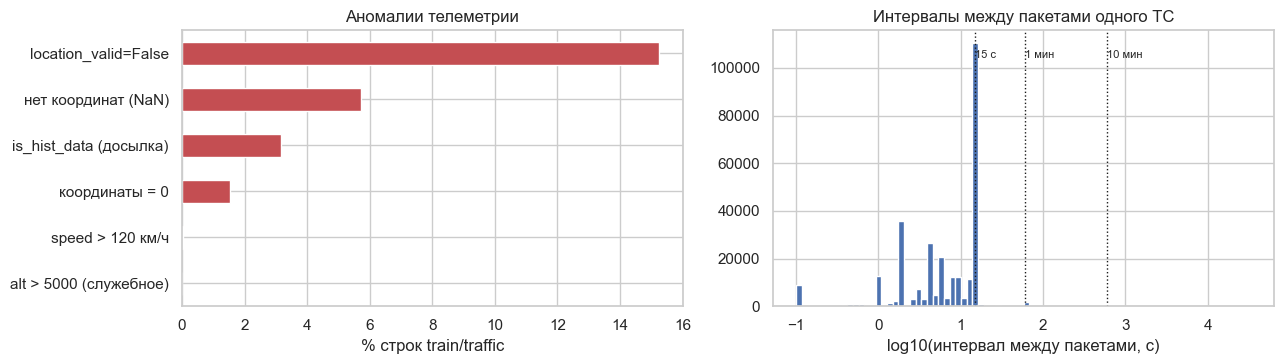

медиана интервала: 8.0 с | разрывов > 2 мин: 206 | > 10 мин: 101


In [10]:
def anomaly_flags(t):
    return pd.DataFrame({
        "нет координат (NaN)": t.lat.isna(),
        "location_valid=False": ~t.location_valid.astype(bool),
        "координаты = 0": (t.lat.abs() < 1) & t.lat.notna(),
        "speed > 120 км/ч": t.speed > 120,
        "alt > 5000 (служебное)": t.alt > 5000,
        "is_hist_data (досылка)": t.is_hist_data.astype(bool),
    })

anom = pd.concat({sp: anomaly_flags(traffic[sp]).mean() * 100 for sp in ["train", "test"]}, axis=1).round(2)
display(anom.rename(columns=lambda c: f"{c}, %"))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
anom["train"].sort_values().plot.barh(ax=axes[0], color=sns.color_palette("deep")[3])
axes[0].set_xlabel("% строк train/traffic"); axes[0].set_title("Аномалии телеметрии")
t = traffic["train"].sort_values(["tr_id", "event_time"])
dt = t.groupby("tr_id").event_time.diff().dt.total_seconds().dropna()
axes[1].hist(np.log10(dt.clip(lower=0.1)), bins=80, color=sns.color_palette("deep")[0])
for v, lab in [(15, "15 с"), (60, "1 мин"), (600, "10 мин")]:
    axes[1].axvline(np.log10(v), color="k", ls=":", lw=1); axes[1].text(np.log10(v), axes[1].get_ylim()[1] * 0.9, lab, fontsize=8)
axes[1].set_xlabel("log10(интервал между пакетами, с)"); axes[1].set_title("Интервалы между пакетами одного ТС")
plt.tight_layout(); plt.show()
print("медиана интервала:", dt.median(), "с | разрывов > 2 мин:", int((dt > 120).sum()), "| > 10 мин:", int((dt > 600).sum()))

Пакеты приходят в среднем раз в ~8–15 секунд, но бывают разрывы до
нескольких часов. Для модели это значит, что признаки «за последние N минут»
могут оказаться пустыми, а сам разрыв связи — тоже признак (`last_fix_age`).
Для бэкенда это прямо то, что требует ТЗ про деградацию при обрыве связи.

Функция очистки, которую применяем дальше (её же стоит перенести в бэкенд):

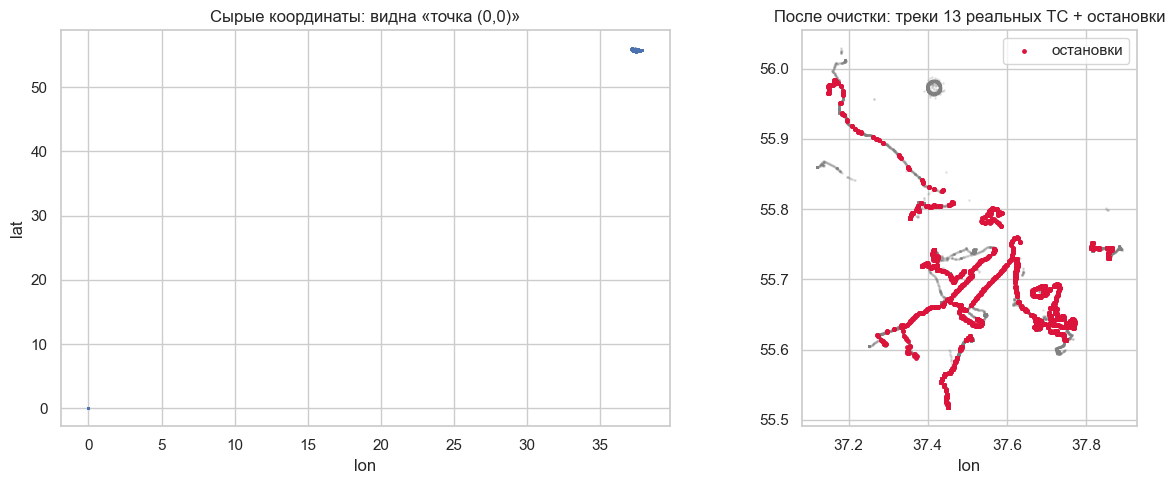

In [11]:
def clean_traffic(t):
    t = t.copy()
    bad_xy = (~t.location_valid.astype(bool)) | t.lat.isna() | (t.lat.abs() < 1) | (t.lon.abs() < 1)
    t.loc[bad_xy, ["lon", "lat"]] = np.nan
    t.loc[t.speed > 120, "speed"] = np.nan
    t.loc[t.alt > 5000, "alt"] = np.nan
    return t.sort_values(["tr_id", "event_time"]).reset_index(drop=True)

traffic_c = {sp: clean_traffic(traffic[sp]) for sp in traffic}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
raw = traffic["train"].dropna(subset=["lat"])
axes[0].scatter(raw.lon, raw.lat, s=1, alpha=0.3)
axes[0].set_title("Сырые координаты: видна «точка (0,0)»"); axes[0].set_xlabel("lon"); axes[0].set_ylabel("lat")
cl = traffic_c["train"].dropna(subset=["lat"])
cl_r = cl[cl.tr_id.isin(REAL_TR)]
axes[1].scatter(cl_r.lon, cl_r.lat, s=1, alpha=0.15, c="grey")
s_real = sched["test"].groupby("tt_action_item_id").first()
axes[1].scatter(s_real.stop_lon, s_real.stop_lat, s=6, c="crimson", label="остановки")
axes[1].set_title("После очистки: треки 13 реальных ТС + остановки"); axes[1].set_xlabel("lon"); axes[1].legend()
axes[1].set_aspect(1 / np.cos(np.radians(55.7)))
plt.tight_layout(); plt.show()

## [1.3] 1D-визуализация: raincloud plot

Как в Задании 1: облако (KDE) + дождь (точки с jittering) + коробка. Усы
по умолчанию — полный размах `whis=(0, 100)`, и их можно заменить другими
оценками выборки одним параметром: пара чисел задаёт перцентили, одно число —
множитель IQR по Тьюки. Теперь классов несколько, и у `ptitprince` при
нескольких классах путаются цвета «дождя». Поэтому три слоя рисуем сами, по
тому же принципу.

Цвета и формы маркеров классов фиксируем один раз и используем во всех
графиках ниже.

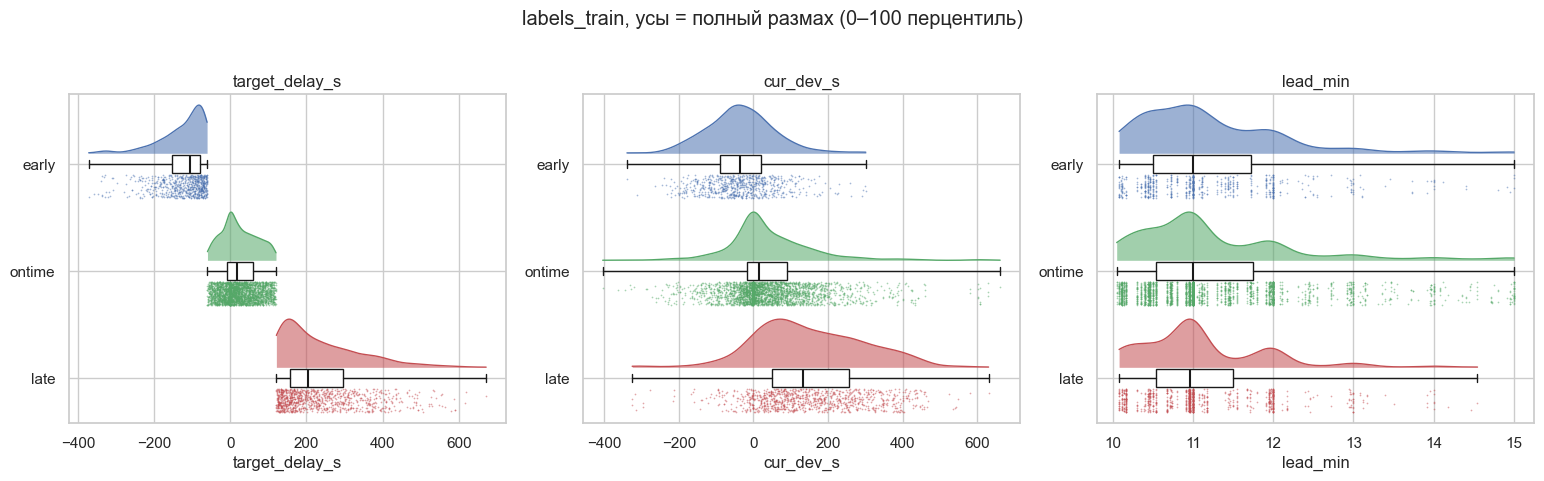

In [12]:
CLASS_ORDER = ["early", "ontime", "late"]
pal = sns.color_palette("deep")
CLASS_STYLE = {
    "early": dict(color=pal[0], marker="v", label="early (< −60 с)"),
    "ontime": dict(color=pal[2], marker="o", label="ontime"),
    "late": dict(color=pal[3], marker="^", label="late (> +120 с)"),
}
CLASS_PAL = [CLASS_STYLE[c]["color"] for c in CLASS_ORDER]

def raincloud_by_class(df, features, class_col, order, palette, whis=(0, 100), title=None,
                       cloud_h=0.45, box_h=0.10, rain_h=0.22, point_size=1.5, max_points=3000):
    # облако (KDE) над осью класса, коробка на оси, дождь (jitter) под ней.
    # Слои рисуем сами: у ptitprince при нескольких классах цвета «дождя» путаются.
    rng_ = np.random.RandomState(RNG_SEED)
    fig, axes = plt.subplots(1, len(features), figsize=(5.2 * len(features), 1.1 + 1.2 * len(order)), squeeze=False)
    for ax, feat in zip(axes.flat, features):
        for k, (cls, color) in enumerate(zip(order, palette)):
            x = df.loc[df[class_col] == cls, feat].dropna().to_numpy()
            if len(x) < 2:
                continue
            y0 = -k
            grid = np.linspace(x.min(), x.max(), 300)
            dens = spstats.gaussian_kde(x)(grid) if np.ptp(x) > 0 else np.zeros_like(grid)
            dens = dens / dens.max() * cloud_h if dens.max() > 0 else dens
            ax.fill_between(grid, y0 + box_h, y0 + box_h + dens, color=color, alpha=0.55, lw=0)
            ax.plot(grid, y0 + box_h + dens, color=color, lw=1)
            xs = x if len(x) <= max_points else rng_.choice(x, max_points, replace=False)
            ax.scatter(xs, y0 - box_h - rng_.uniform(0, rain_h, len(xs)), s=point_size, color=color, alpha=0.5, lw=0)
            q1, med, q3 = np.percentile(x, [25, 50, 75])
            lo, hi = (np.percentile(x, whis) if isinstance(whis, tuple)
                      else (x[x >= q1 - whis * (q3 - q1)].min(), x[x <= q3 + whis * (q3 - q1)].max()))
            ax.bxp([dict(med=med, q1=q1, q3=q3, whislo=lo, whishi=hi, fliers=[])], positions=[y0], vert=False,
                   widths=box_h * 1.6, showfliers=False, patch_artist=True, manage_ticks=False,
                   boxprops=dict(facecolor="white", edgecolor="k", lw=1), medianprops=dict(color="k", lw=1.5),
                   whiskerprops=dict(color="k"), capprops=dict(color="k"))
        ax.set_yticks([-k for k in range(len(order))]); ax.set_yticklabels(order)
        ax.set_ylim(-len(order) + 1 - box_h - rain_h - 0.1, box_h + cloud_h + 0.1)
        ax.set_title(feat); ax.set_xlabel(feat)
    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout(); plt.show()

raincloud_by_class(lab_tr, ["target_delay_s", "cur_dev_s", "lead_min"], "target_class", CLASS_ORDER, CLASS_PAL,
                   title="labels_train, усы = полный размах (0–100 перцентиль)")

Классы по `target_delay_s` разделены по построению, поэтому интереснее
средняя панель: у `cur_dev_s` классы **сильно перекрываются**. Среди «late»
много точек, где на последней остановке задержка была около 0, и наоборот.
Именно в этой части подсказка ошибается, и ради неё нужна модель. То же с усами
по 5–95 перцентилям:

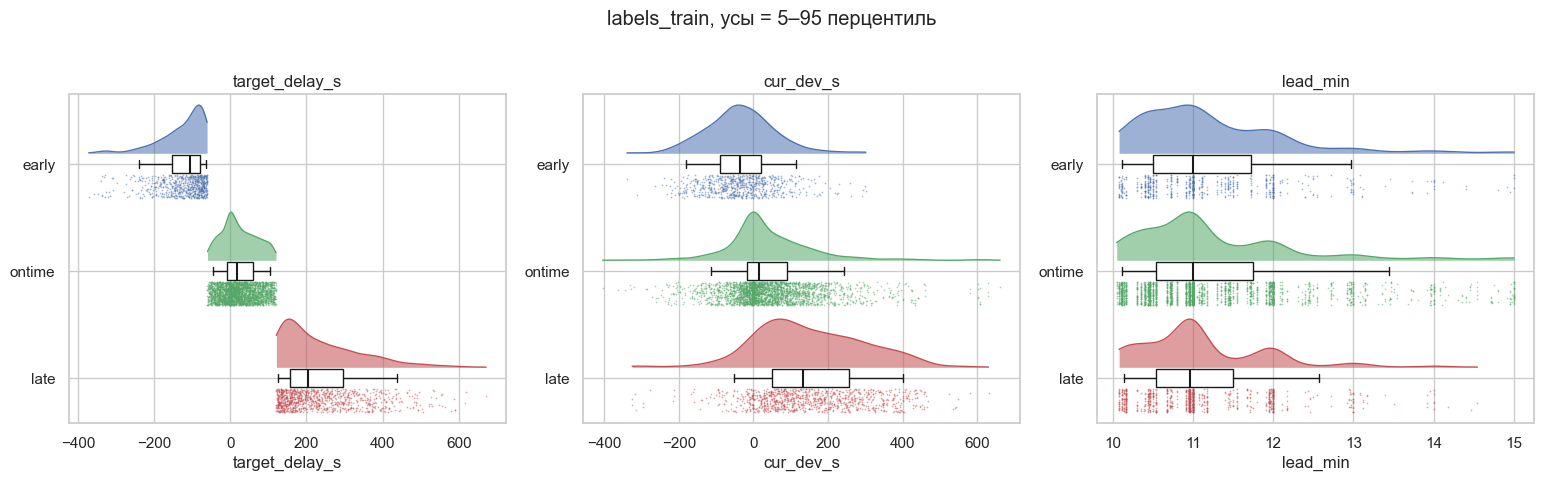

In [13]:
raincloud_by_class(lab_tr, ["target_delay_s", "cur_dev_s", "lead_min"], "target_class", CLASS_ORDER, CLASS_PAL,
                   whis=(5, 95), title="labels_train, усы = 5–95 перцентиль")

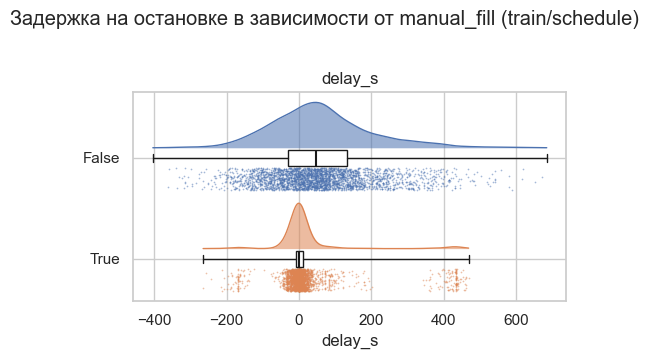

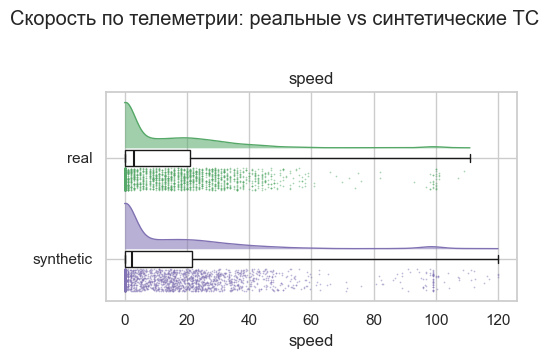

In [14]:
s_all = sched["train"].copy()
s_all["kind"] = np.where(s_all.tr_id.isin(REAL_TR), "real", "synthetic")
s_all["manual_fill"] = s_all.manual_fill.astype(str)
raincloud_by_class(s_all, ["delay_s"], "manual_fill", ["False", "True"], [pal[0], pal[1]],
                   title="Задержка на остановке в зависимости от manual_fill (train/schedule)")
tmp = clean_traffic(tr_tel)
tmp["kind"] = np.where(tmp.tr_id.isin(REAL_TR), "real", "synthetic")
raincloud_by_class(tmp.dropna(subset=["speed"]).sample(20000, random_state=RNG_SEED), ["speed"], "kind",
                   ["real", "synthetic"], [pal[2], pal[4]], title="Скорость по телеметрии: реальные vs синтетические ТС")

- При `manual_fill=True` облако задержек схлопывается в пик на 0: это
  подтверждает, что у таких остановок «факт = план».
- Скорости реальных и синтетических ТС распределены одинаково, пик на 0 — это
  стоянки на остановках, светофорах и конечных. Судя по всему, синтетика —
  это сдвинутые по времени и зашумлённые копии реальных треков.

## [C] Признаки на момент T (без заглядывания в будущее)

Это главный ML-раздел. Для каждой прогнозной точки `(tr_id, T)` считаем
признаки **только по телеметрии с `event_time ≤ T`** и по **плановому**
расписанию. Факты расписания не используем вообще, даже прошлые: в validate их
нет, и признаки должны считаться одинаково на train, test, validate и на живом
потоке.

### C.1 Восстанавливаем факт прибытия из GPS

Вместо фактов берём телеметрию. Прибытие на остановку — момент, когда ТС ближе
всего к точке остановки (`geom`) в окне ±15 мин от планового времени, при
условии, что расстояние меньше 60 м. Сначала проверим на test, где факт
известен, насколько восстановленная задержка совпадает с настоящей.

покрытие: 83.8% остановок


,n,"MAE, с","медиана |ошибки|, с",r Пирсона
manual_fill,,,,
False,4295.0,27.57,3.0,0.75
True,364.0,140.16,79.5,0.05


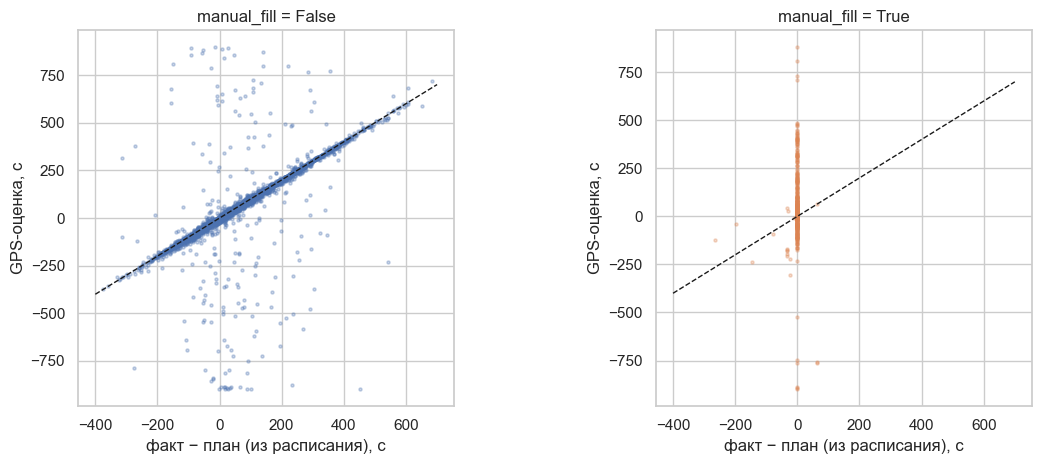

In [15]:
def dist_m(lon1, lat1, lon2, lat2):
    k = np.pi / 180
    return 6371000 * np.hypot((lon1 - lon2) * k * np.cos(lat2 * k), (lat1 - lat2) * k)

ARR_WIN, ARR_RADIUS = 900, 60  # окно поиска ±15 мин, радиус «на остановке» 60 м

def tele_arrays(tc):
    out = {}
    for tid, g in tc.groupby("tr_id"):
        out[tid] = dict(ts=to_sec(g.event_time), lon=g.lon.values, lat=g.lat.values, speed=g.speed.values)
    return out

def stop_arrays(s):
    out = {}
    for tid, g in s.sort_values("time_begin").groupby("tr_id"):
        out[tid] = dict(id=g.tt_action_item_id.values, plan=to_sec(g.time_begin), lon=g.stop_lon.values,
                        lat=g.stop_lat.values, mf=g.manual_fill.values.astype(int))
    return out

def estimate_arrival(tg, plan, slon, slat, t_max=None):
    # оценка момента прибытия по GPS; t_max — «сейчас» (берём только пакеты ≤ t_max)
    hi = plan + ARR_WIN if t_max is None else min(plan + ARR_WIN, t_max)
    a, b = np.searchsorted(tg["ts"], plan - ARR_WIN), np.searchsorted(tg["ts"], hi, side="right")
    if b <= a:
        return np.nan
    d = dist_m(tg["lon"][a:b], tg["lat"][a:b], slon, slat)
    if np.all(np.isnan(d)):
        return np.nan
    j = np.nanargmin(d)
    return tg["ts"][a + j] if d[j] < ARR_RADIUS else np.nan

TELE = {sp: tele_arrays(traffic_c[sp]) for sp in traffic_c}
STOPS = {sp: stop_arrays(sched[sp]) for sp in sched}

st = sched["test"].sort_values(["tr_id", "time_begin"]).reset_index(drop=True)
est = []
for r in st.itertuples():
    tg = TELE["test"].get(r.tr_id)
    arr = np.nan if tg is None else estimate_arrival(tg, r.time_begin.value // 10**9, r.stop_lon, r.stop_lat)
    est.append(arr - r.time_begin.value // 10**9)
st["gps_delay_s"] = est
ok = st.dropna(subset=["gps_delay_s"])
print(f"покрытие: {len(ok) / len(st):.1%} остановок")
display(ok.groupby("manual_fill").apply(lambda g: pd.Series({
    "n": len(g), "MAE, с": (g.gps_delay_s - g.delay_s).abs().mean(),
    "медиана |ошибки|, с": (g.gps_delay_s - g.delay_s).abs().median(),
    "r Пирсона": g[["gps_delay_s", "delay_s"]].corr().iloc[0, 1]})).round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for mf, ax in zip([False, True], axes):
    g = ok[ok.manual_fill == mf]
    ax.scatter(g.delay_s, g.gps_delay_s, s=5, alpha=0.3, color=pal[0] if not mf else pal[1])
    ax.plot([-400, 700], [-400, 700], "k--", lw=1)
    ax.set_xlabel("факт − план (из расписания), с"); ax.set_ylabel("GPS-оценка, с")
    ax.set_title(f"manual_fill = {mf}"); ax.set_box_aspect(1)
plt.tight_layout(); plt.show()

**Восстановление работает.** Для обычных остановок (`manual_fill=False`)
медианная ошибка около 3 секунд, точки лежат на диагонали. Для
`manual_fill=True` GPS показывает реальное прибытие, а в расписании стоит «0».
Это ещё раз подтверждает, что у ручных остановок факт взят по плану. Отсюда
выводы:

- **историю отклонений ТС можно честно получить из телеметрии** — и на
  validate, и на живом NDTP-потоке (это же требование ТЗ к бэкенду:
  «отклонение от графика на текущий момент»);
- для целевой остановки с `manual_fill=True` нужно предсказывать скорее
  «как запишут в расписании», то есть около 0, а не реальное опоздание.

### C.2 Набор признаков

| Группа | Признаки | Откуда |
|---|---|---|
| подсказка | `cur_dev_s` | points |
| геометрия прогноза | `lead_s` (T → план цели), `hour`, `n_stops_between`, `plan_gap_prev_s` | план |
| флаги ручного заполнения | `tgt_manual_fill`, `prev_manual_fill`, `mf_share_next` | план |
| история по GPS | `gps_last_dev`, `gps_med3`, `gps_med5`, `gps_slope`, `gps_n`, `gps_age_s` | телеметрия ≤ T |
| динамика движения | `spd5`, `spd15`, `stop5`, `stop15` (доля пакетов со скоростью < 3 км/ч), `n_pkt15` | телеметрия ≤ T |
| положение | `dist_tgt_m` (по прямой до цели), `req_speed_kmh` (сколько надо ехать, чтобы успеть), `last_fix_age_s` | телеметрия ≤ T |

Все окна строго `≤ T`: `estimate_arrival` получает `t_max=T`.

**Как сопоставляем онлайн (на момент T).** Если просто обрезать окно по T,
получаются ложные «ранние прибытия». ТС проезжает рядом с остановкой
встречного направления или той же точкой на петле маршрута, и без будущих
пакетов этого не отличить. Поэтому `gps_history`:

1. идёт по остановкам **в порядке маршрута**, и каждое следующее прибытие ищет
   только **после** предыдущего;
2. засчитывает прибытие, только если ТС уже **отъехало** от остановки (после
   минимума расстояние выросло хотя бы на 30 м). Иначе остановка ещё «не
   пройдена»;
3. ищет в узком асимметричном окне: от −7 до +12 минут от плана (опережение
   бывает меньше, чем опоздание);
4. пропускает остановки с `manual_fill=True`: их «факт» в расписании условный.

Медианы по последним 3 и 5 остановкам (`gps_med3`, `gps_med5`) устойчивее к
единичным ошибкам сопоставления, чем одно последнее значение.

In [16]:
WIN_EARLY, WIN_LATE, LEAVE_M = 420, 720, 30

def gps_history(tg, sg, T, back=3600, fwd=300):
    # -> массив (plan, delay, arrival) по пройденным к моменту T автоматическим остановкам
    cand = np.where((sg["plan"] >= T - back) & (sg["plan"] <= T + fwd) & (sg["mf"] == 0))[0]
    hist, prev = [], -np.inf
    for i in cand:
        lo, hi = max(sg["plan"][i] - WIN_EARLY, prev + 1), min(sg["plan"][i] + WIN_LATE, T)
        a, b = np.searchsorted(tg["ts"], lo), np.searchsorted(tg["ts"], hi, side="right")
        if b - a < 2:
            continue
        d = dist_m(tg["lon"][a:b], tg["lat"][a:b], sg["lon"][i], sg["lat"][i])
        if np.all(np.isnan(d)):
            continue
        j = np.nanargmin(d)
        after = d[j + 1:]
        after = after[~np.isnan(after)]
        if d[j] < ARR_RADIUS and len(after) and after.max() > d[j] + LEAVE_M:
            prev = tg["ts"][a + j]
            hist.append((sg["plan"][i], prev - sg["plan"][i], prev))
    return np.array(hist, dtype=float).reshape(-1, 3)


def build_features(pts, split):
    TG, SG = TELE[split], STOPS[split]
    rows = []
    for r in pts.itertuples(index=False):
        T = r.T.value // 10**9
        tgt_plan = r.target_time_begin.value // 10**9
        f = dict(sample_id=r.sample_id, tr_id=r.tr_id, cur_dev_s=r.cur_dev_s,
                 lead_s=tgt_plan - T, hour=r.T.hour + r.T.minute / 60)
        sg, tg = SG.get(r.tr_id), TG.get(r.tr_id)
        # --- плановое расписание
        k = np.where(sg["id"] == r.target_stop_id)[0]
        tk = k[0] if len(k) else None
        f["tgt_manual_fill"] = sg["mf"][tk] if tk is not None else np.nan
        before = np.where(sg["plan"] <= T)[0]
        between = (sg["plan"] > T) & (sg["plan"] < tgt_plan)
        f["n_stops_between"] = int(between.sum())
        f["mf_share_next"] = sg["mf"][between].mean() if between.any() else np.nan
        f["prev_manual_fill"] = sg["mf"][before[-1]] if len(before) else np.nan
        f["plan_gap_prev_s"] = T - sg["plan"][before[-1]] if len(before) else np.nan
        # --- история отклонений по GPS (только пакеты <= T, только «автоматические» остановки)
        h = gps_history(tg, sg, T) if tg is not None else np.empty((0, 3))
        d = h[:, 1]
        f.update(gps_n=len(d),
                 gps_last_dev=d[-1] if len(d) else np.nan,
                 gps_med3=np.median(d[-3:]) if len(d) else np.nan,
                 gps_med5=np.median(d[-5:]) if len(d) else np.nan,
                 gps_age_s=T - h[-1, 2] if len(d) else np.nan,
                 gps_slope=np.polyfit(h[-5:, 0] / 60, d[-5:], 1)[0] if len(d) >= 3 else np.nan)
        # --- динамика и положение
        if tg is not None:
            b = np.searchsorted(tg["ts"], T, side="right")
            for w in (5, 15):
                a = np.searchsorted(tg["ts"], T - 60 * w)
                sp_ = tg["speed"][a:b]
                sp_ = sp_[~np.isnan(sp_)]
                f[f"spd{w}"] = sp_.mean() if len(sp_) else np.nan
                f[f"stop{w}"] = (sp_ < 3).mean() if len(sp_) else np.nan
                if w == 15:
                    f["n_pkt15"] = b - a
            valid = np.where(~np.isnan(tg["lat"][:b]))[0]
            if len(valid) and tk is not None:
                j = valid[-1]
                f["last_fix_age_s"] = T - tg["ts"][j]
                f["dist_tgt_m"] = dist_m(tg["lon"][j], tg["lat"][j], sg["lon"][tk], sg["lat"][tk])
                f["req_speed_kmh"] = f["dist_tgt_m"] / max(f["lead_s"], 60) * 3.6
        rows.append(f)
    X = pd.DataFrame(rows)
    if "target_delay_s" in pts:
        X = X.merge(pts[["sample_id", "target_delay_s", "target_class"]], on="sample_id")
    return X

FE = {sp: build_features(points[sp], sp) for sp in ["train", "test", "validate"]}
FEATS = [c for c in FE["train"].columns if c not in ("sample_id", "tr_id", "target_delay_s", "target_class")]
Path("features").mkdir(exist_ok=True)
for sp, X in FE.items():
    X.to_csv(Path("features") / f"features_{sp}.csv", index=False)
print({sp: X.shape for sp, X in FE.items()})
FE["train"].head()

{'train': (4434, 26), 'test': (353, 26), 'validate': (151, 24)}


,sample_id,tr_id,cur_dev_s,lead_s,hour,tgt_manual_fill,n_stops_between,mf_share_next,prev_manual_fill,plan_gap_prev_s,gps_n,gps_last_dev,gps_med3,gps_med5,gps_age_s,gps_slope,spd5,stop5,spd15,stop15,n_pkt15,last_fix_age_s,dist_tgt_m,req_speed_kmh,target_delay_s,target_class
0,122048_1767665400,122048,0.0,720,2.166667,1,0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0.347826,1.000000,3.461538,0.830769,66,8.0,38.518931,0.192595,-25.0,ontime
1,122048_1767665700,122048,0.0,660,2.250000,1,4,1.0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0.285714,1.000000,0.242424,1.000000,66,6.0,756.868808,4.128375,0.0,ontime
2,122048_1767666000,122048,0.0,720,2.333333,1,8,1.0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0.285714,1.000000,0.307692,1.000000,65,2.0,1536.792060,7.683960,0.0,ontime
3,122048_1767666300,122048,0.0,720,2.416667,1,7,1.0,1.0,0.0,0,NaN,NaN,NaN,NaN,NaN,5.695652,0.391304,2.200000,0.784615,68,6.0,2164.830633,10.824153,0.0,ontime
4,122048_1767666600,122048,0.0,660,2.500000,1,6,1.0,1.0,0.0,0,NaN,NaN,NaN,NaN,NaN,15.500000,0.045455,7.242424,0.469697,74,6.0,2886.713373,15.745709,0.0,ontime


In [17]:
FE["train"]["kind"] = np.where(FE["train"].tr_id.isin(REAL_TR), "real", "synthetic")
describe_dataset(FE["train"], FEATS, "target_class", "features_train")

===== features_train =====
Размерность: 4434 объектов x 27 признаков

Тип каждого признака:


,sample_id,tr_id,cur_dev_s,lead_s,hour,tgt_manual_fill,n_stops_between,mf_share_next,prev_manual_fill,plan_gap_prev_s,gps_n,gps_last_dev,gps_med3,gps_med5,gps_age_s,gps_slope,spd5,stop5,spd15,stop15,n_pkt15,last_fix_age_s,dist_tgt_m,req_speed_kmh,target_delay_s,target_class,kind
dtype,object,int64,float64,int64,float64,int64,int64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,object,object



Классы (target_class) и число объектов в каждом:


target_class,early,late,ontime
n объектов,679,998,2757



Описательные статистики признаков:


...

,cur_dev_s,lead_s,hour,tgt_manual_fill,n_stops_between,mf_share_next,prev_manual_fill,plan_gap_prev_s,gps_n,gps_last_dev,gps_med3,gps_med5,gps_age_s,gps_slope,spd5,stop5,spd15,stop15,n_pkt15,last_fix_age_s,dist_tgt_m,req_speed_kmh
target_class,,,,,,,,,,,,,,,,,,,,,,
early,0,0,0,0,0,12,3,3,0,27,27,27,27,39,0,0,0,0,0,0,0,0
late,0,0,0,0,0,10,10,10,0,37,37,37,37,68,0,0,0,0,0,0,0,0
ontime,0,0,0,0,0,171,84,84,0,457,457,457,457,515,10,10,1,1,0,1,1,1



Число объектов хотя бы с одним NaN, по классам:


target_class,early,late,ontime
n объектов с NaN,45,78,616



Число значений, равных 0, по признакам и классам:


,cur_dev_s,lead_s,hour,tgt_manual_fill,n_stops_between,mf_share_next,prev_manual_fill,plan_gap_prev_s,gps_n,gps_last_dev,gps_med3,gps_med5,gps_age_s,gps_slope,spd5,stop5,spd15,stop15,n_pkt15,last_fix_age_s,dist_tgt_m,req_speed_kmh
target_class,,,,,,,,,,,,,,,,,,,,,,
early,10,0,0,671,12,653,649,97,27,0,1,0,0,0,57,5,28,0,0,71,0,0
late,16,0,0,969,10,958,959,155,37,1,4,5,0,0,96,1,36,0,0,119,0,0
ontime,250,0,2,2081,171,1914,2037,372,457,7,8,9,0,0,553,47,382,3,1,280,0,0


## [1.4] 2D-визуализация: настраиваемый pairgrid

Те же `DEFAULT_CFG`, `apply_axis_style` и `custom_pairgrid`, что в Задании 1.
Вне диагонали — scatter, где классы различаются цветом **и** формой маркера;
на диагонали — KDE каждого класса с прозрачной заливкой. Берём таргет и пять
самых информативных признаков.

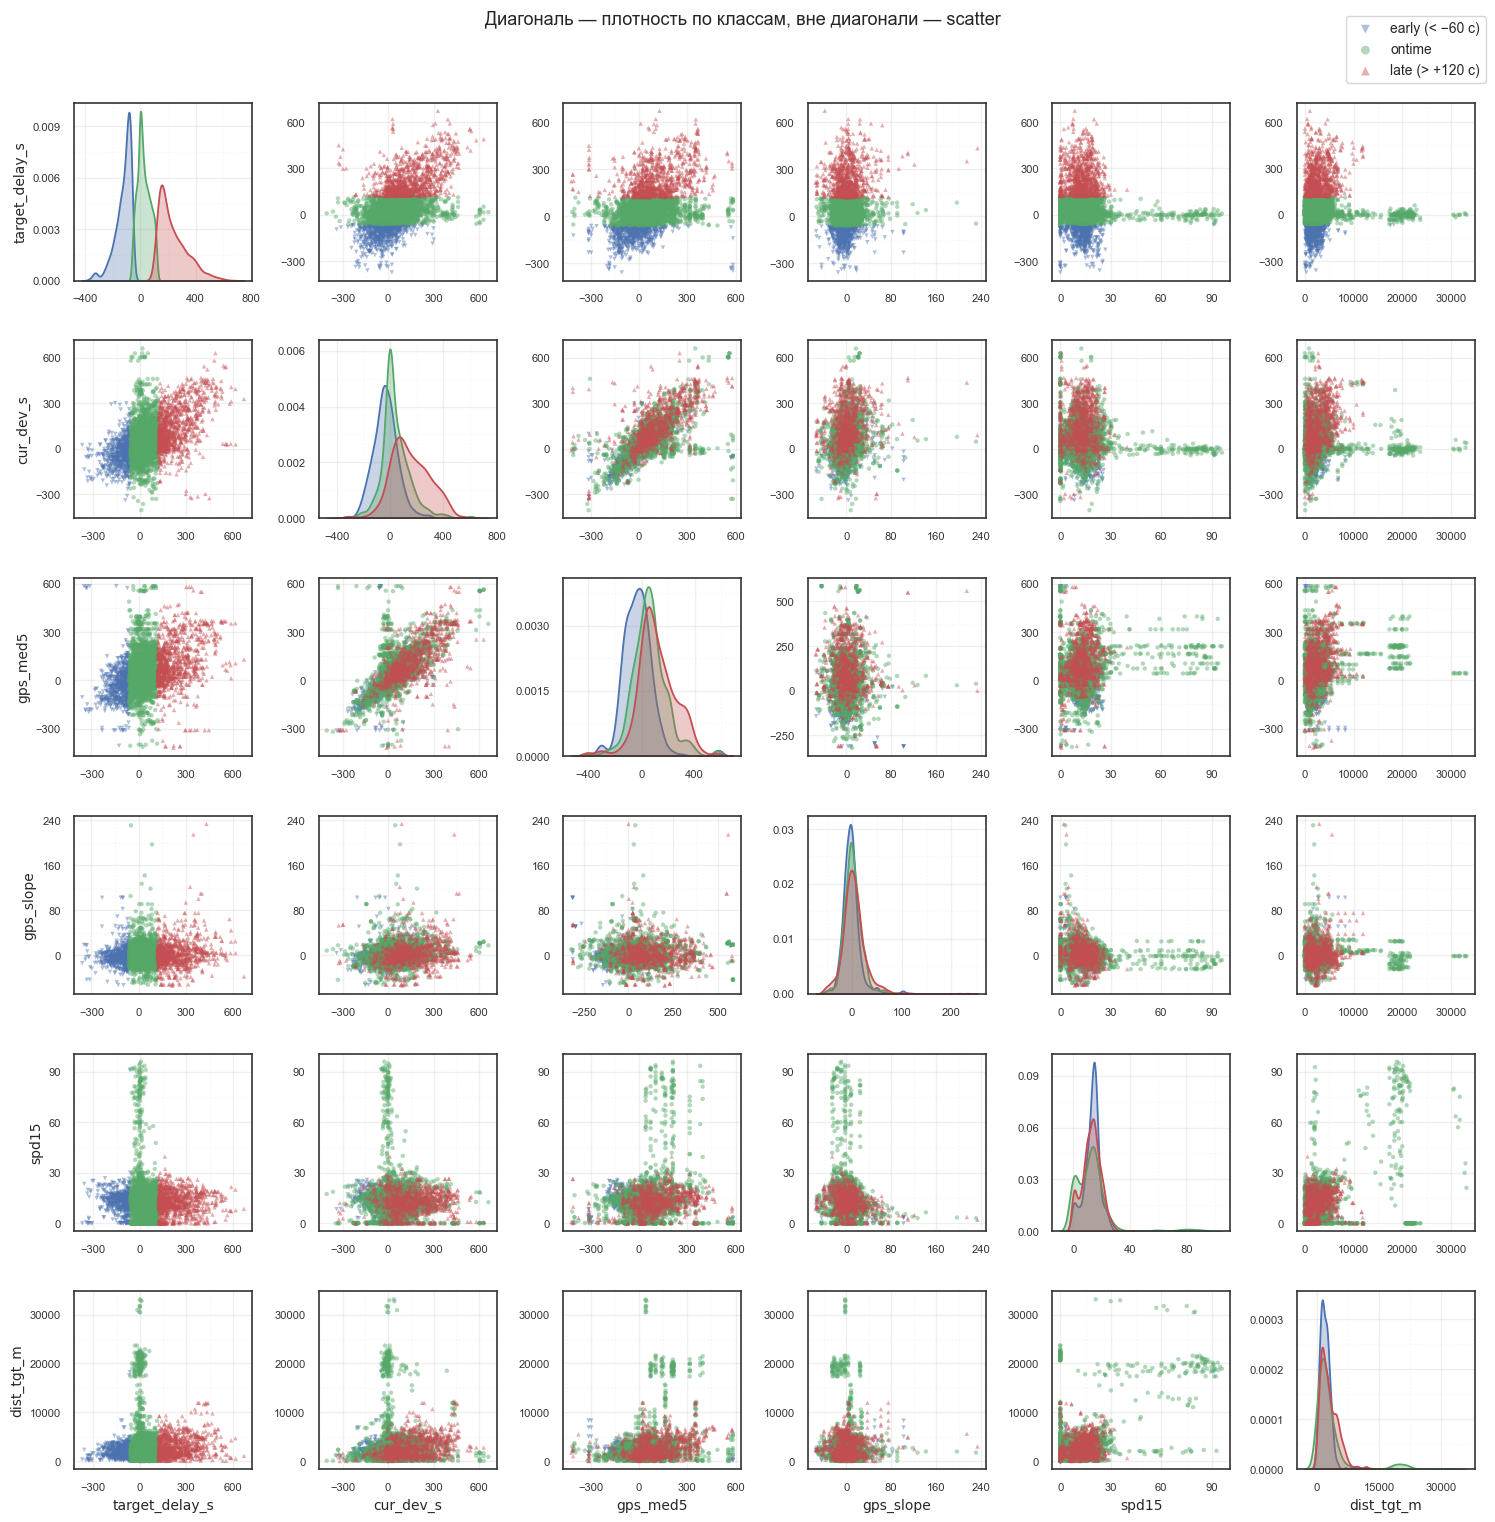

In [18]:
DEFAULT_CFG = dict(
    axis_color="#333333", axis_linewidth=1.2, major_tick_step=None, minor_ticks=1,
    show_grid=True, grid_alpha=0.3, square_aspect=True,
    label_fontsize=10, label_fontfamily="DejaVu Sans", tick_fontsize=8, title_fontsize=13,
    show_legend=True, show_suptitle=True, point_alpha=0.45, point_size=10, density_alpha=0.30,
)

def apply_axis_style(ax, cfg, xlabel, ylabel, show_xlabel=True, show_ylabel=True):
    for spine in ax.spines.values():
        spine.set_color(cfg["axis_color"]); spine.set_linewidth(cfg["axis_linewidth"])
    ax.tick_params(width=cfg["axis_linewidth"], colors=cfg["axis_color"], labelsize=cfg["tick_fontsize"])
    if cfg["major_tick_step"]:
        ax.xaxis.set_major_locator(mticker.MultipleLocator(cfg["major_tick_step"]))
        ax.yaxis.set_major_locator(mticker.MultipleLocator(cfg["major_tick_step"]))
    else:
        ax.xaxis.set_major_locator(mticker.MaxNLocator(4)); ax.yaxis.set_major_locator(mticker.MaxNLocator(4))
    ax.xaxis.set_minor_locator(mticker.AutoMinorLocator(cfg["minor_ticks"] + 1))
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(cfg["minor_ticks"] + 1))
    if cfg["show_grid"]:
        ax.grid(True, which="major", alpha=cfg["grid_alpha"])
        ax.grid(True, which="minor", alpha=cfg["grid_alpha"] * 0.5, linestyle=":")
    else:
        ax.grid(False)
    if cfg["square_aspect"]:
        ax.set_box_aspect(1)
    ax.set_xlabel(xlabel if show_xlabel else "", fontsize=cfg["label_fontsize"], fontfamily=cfg["label_fontfamily"])
    ax.set_ylabel(ylabel if show_ylabel else "", fontsize=cfg["label_fontsize"], fontfamily=cfg["label_fontfamily"])

def custom_pairgrid(df, features, class_col, class_style, cfg, title="Диагональ — плотность по классам, вне диагонали — scatter"):
    n = len(features)
    fig, axes = plt.subplots(n, n, figsize=(2.5 * n, 2.5 * n))
    for i, fi in enumerate(features):
        for j, fj in enumerate(features):
            ax = axes[i, j]
            for cls, sty in class_style.items():
                sub = df[df[class_col] == cls]
                if i == j:
                    sns.kdeplot(sub[fi].dropna(), ax=ax, color=sty["color"], fill=True,
                                alpha=cfg["density_alpha"], linewidth=1.3, warn_singular=False)
                else:
                    ax.scatter(sub[fj], sub[fi], marker=sty["marker"], color=sty["color"], alpha=cfg["point_alpha"],
                               s=cfg["point_size"], edgecolors="none", label=sty["label"])
            apply_axis_style(ax, cfg, xlabel=fj, ylabel=fi, show_xlabel=(i == n - 1), show_ylabel=(j == 0))
    if cfg["show_legend"]:
        h, l = axes[0, 1].get_legend_handles_labels()
        fig.legend(h, l, loc="upper right", bbox_to_anchor=(1.0, 1.02), fontsize=cfg["label_fontsize"], markerscale=2)
    if cfg["show_suptitle"]:
        fig.suptitle(title, fontsize=cfg["title_fontsize"], y=1.02)
    plt.tight_layout(); plt.show()

PAIR_FEATS = ["target_delay_s", "cur_dev_s", "gps_med5", "gps_slope", "spd15", "dist_tgt_m"]
custom_pairgrid(FE["train"], PAIR_FEATS, "target_class", CLASS_STYLE, DEFAULT_CFG)

Главное на графике — строка `target_delay_s`:

- против `cur_dev_s` и `gps_med5` виден наклонный «язык»: связь есть, но
  с большим разбросом, и видны **горизонтальные полосы на 0**. Это целевые
  остановки с `manual_fill`, где таргет обнулён независимо от истории;
- у `cur_dev_s` есть вертикальная полоса на 0 (подсказка иногда «пустая»,
  хотя ТС опаздывает). Тут `gps_med5` добавляет информацию;
- кластер точек с `dist_tgt_m` ≈ 20 км и `spd15` до 90 км/ч — это «ошибочные»
  или устаревшие координаты (ТС за 10 минут физически не проедет 20 км по
  городу). Для модели это нормально, но бэкенду стоит фильтровать такие
  скачки (map matching);
- у `spd15` и `dist_tgt_m` связь нелинейная: late-точки чаще встречаются
  при низкой средней скорости и большом расстоянии до цели.

Тот же pairgrid с другими настройками стиля — чтобы показать, что всё
управляется словарём `cfg`:

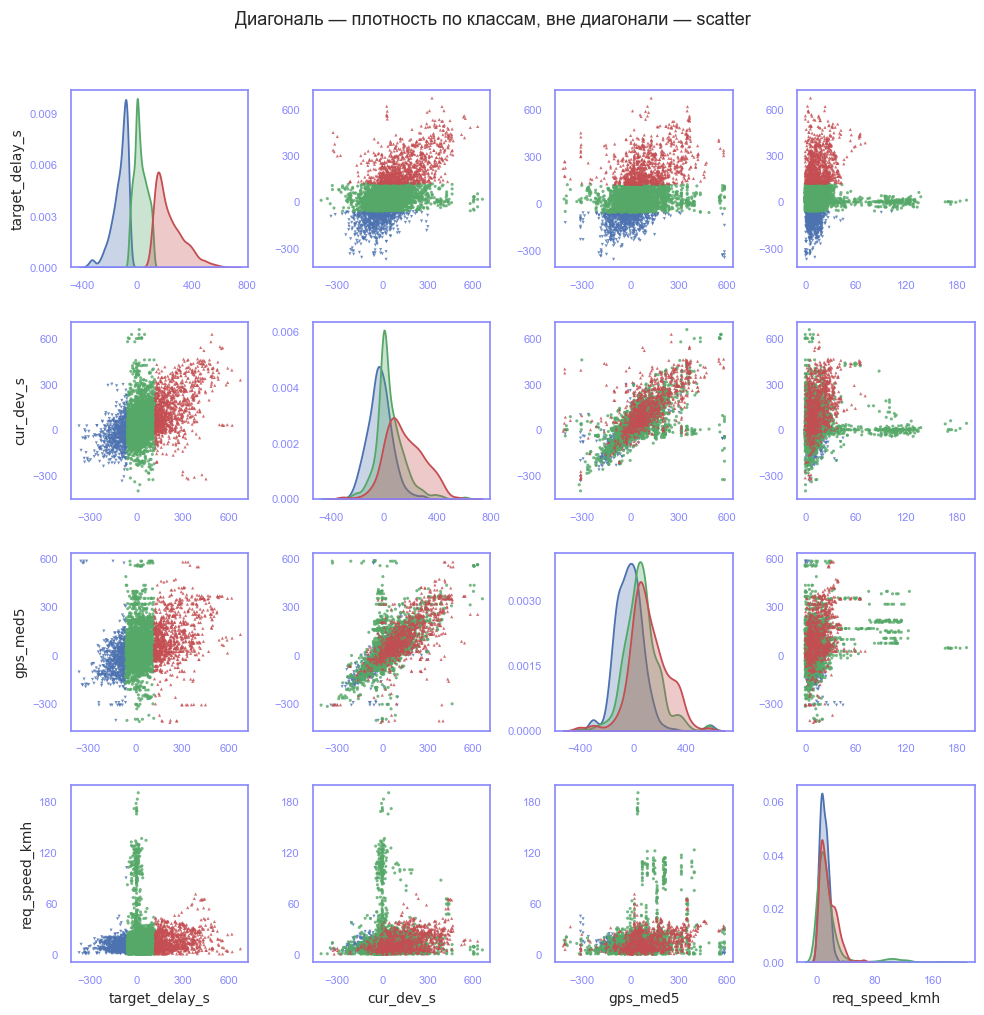

In [19]:
cfg_alt = dict(DEFAULT_CFG)
cfg_alt.update(show_grid=False, show_legend=False, point_alpha=0.8, axis_color="#8888ff", point_size=5)
custom_pairgrid(FE["train"], ["target_delay_s", "cur_dev_s", "gps_med5", "req_speed_kmh"], "target_class", CLASS_STYLE, cfg_alt)

## [1.5] Корреляции Пирсона и Спирмана: heatmap

`corr_matrix` из Задания 1 считает корреляцию попарно через `scipy.stats`, с
попарным удалением NaN. Матрицы строим на всём train и отдельно в каждом
классе.

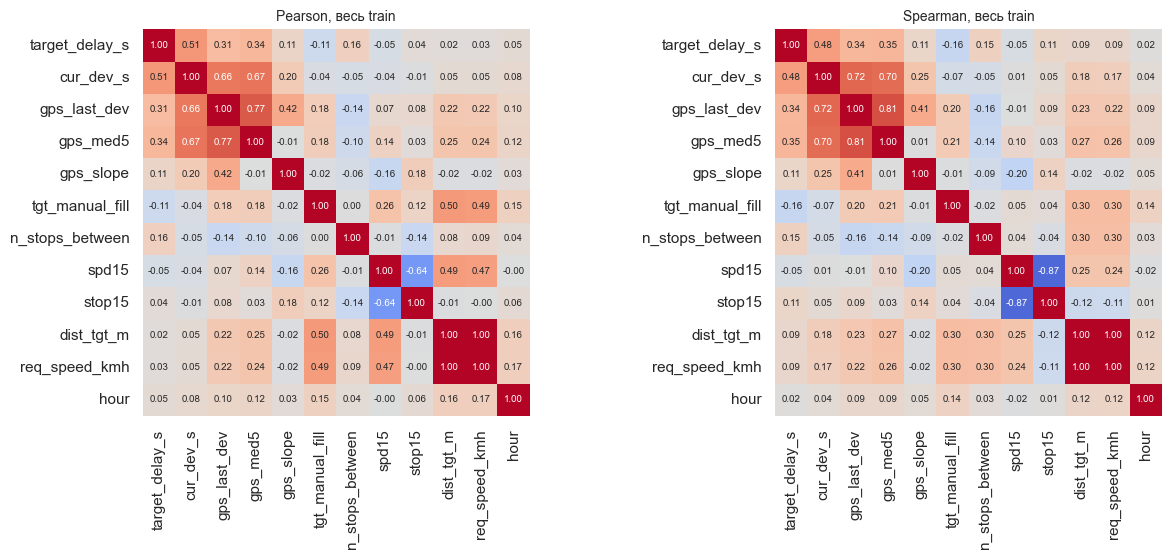

In [20]:
def corr_matrix(df, features, method="pearson"):
    n = len(features)
    mat = np.eye(n)
    for i in range(n):
        for j in range(i + 1, n):
            x, y = df[features[i]], df[features[j]]
            v = x.notna() & y.notna()
            if v.sum() < 3 or x[v].nunique() < 2 or y[v].nunique() < 2:
                r = np.nan
            else:
                r = (spstats.pearsonr if method == "pearson" else spstats.spearmanr)(x[v], y[v])[0]
            mat[i, j] = mat[j, i] = r
    return pd.DataFrame(mat, index=features, columns=features)

def plot_corr_heatmaps(mats_titles, ncols=None, size=3.6, annot_fs=7):
    n = len(mats_titles); ncols = ncols or n; nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(size * ncols * 1.4, size * nrows * 1.25), squeeze=False)
    for ax, (mat, title) in zip(axes.flat, mats_titles):
        sns.heatmap(mat, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, ax=ax,
                    cbar=False, annot_kws={"size": annot_fs})
        ax.set_title(title, fontsize=10)
    for ax in axes.flat[n:]:
        ax.axis("off")
    plt.tight_layout(); plt.show()

CORR_FEATS = ["target_delay_s", "cur_dev_s", "gps_last_dev", "gps_med5", "gps_slope", "tgt_manual_fill",
              "n_stops_between", "spd15", "stop15", "dist_tgt_m", "req_speed_kmh", "hour"]
plot_corr_heatmaps([(corr_matrix(FE["train"], CORR_FEATS, "pearson"), "Pearson, весь train"),
                    (corr_matrix(FE["train"], CORR_FEATS, "spearman"), "Spearman, весь train")], size=4.6)

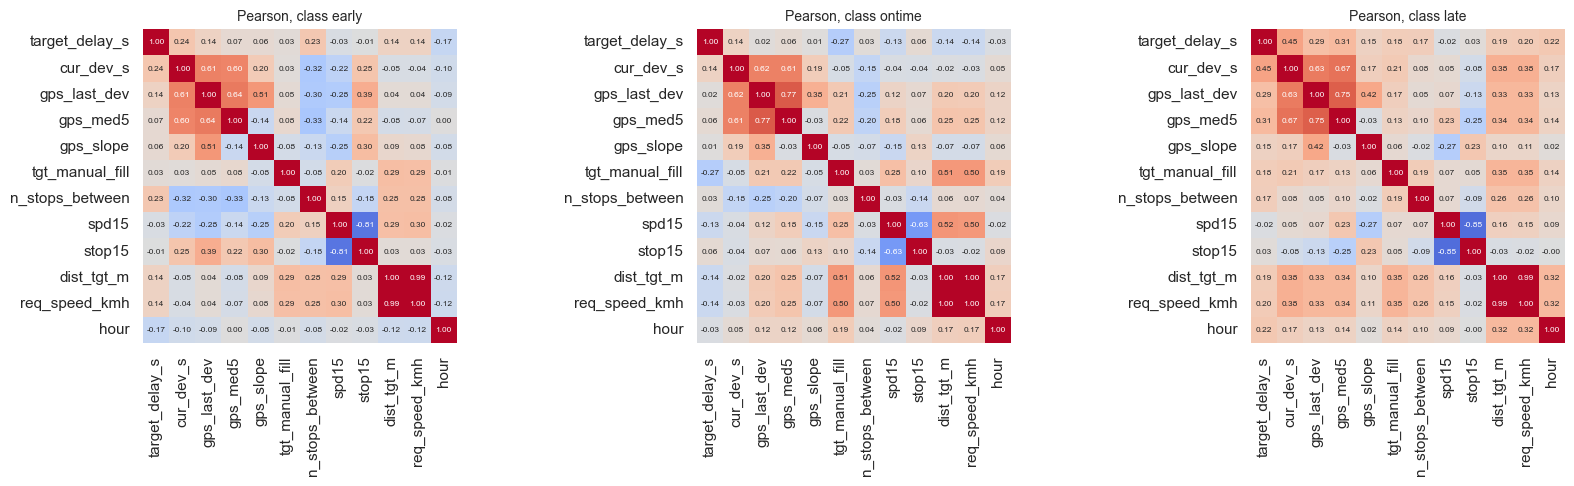

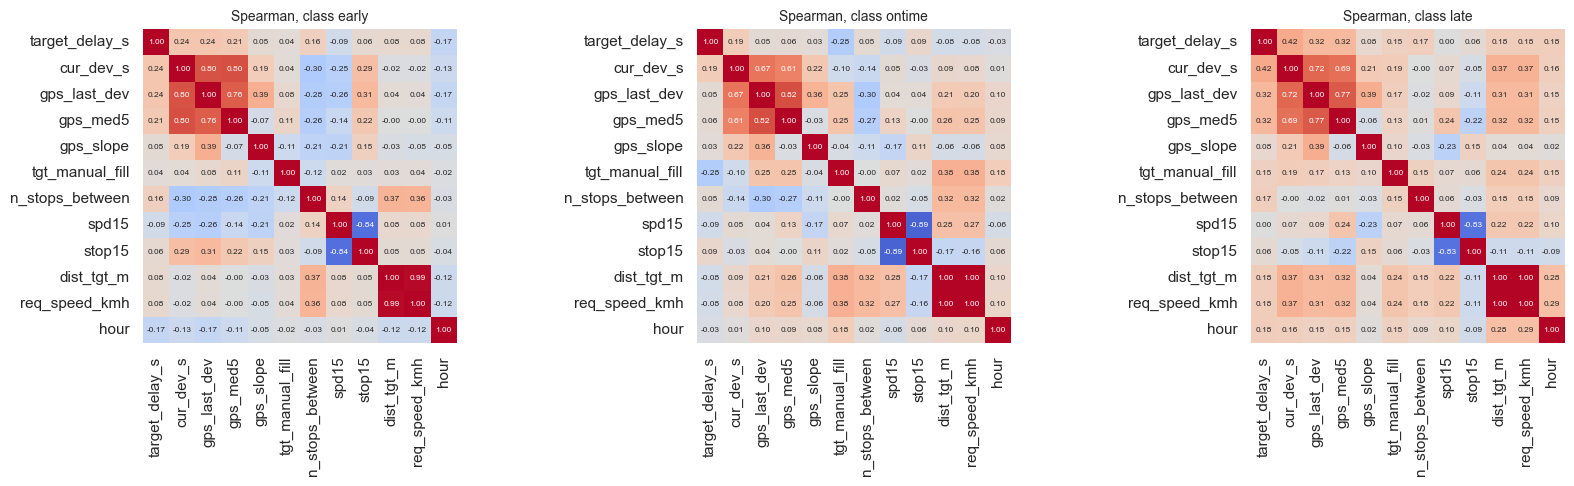

In [21]:
plot_corr_heatmaps([(corr_matrix(FE["train"][FE["train"].target_class == c], CORR_FEATS, "pearson"), f"Pearson, class {c}")
                    for c in CLASS_ORDER], size=4.0, annot_fs=6)
plot_corr_heatmaps([(corr_matrix(FE["train"][FE["train"].target_class == c], CORR_FEATS, "spearman"), f"Spearman, class {c}")
                    for c in CLASS_ORDER], size=4.0, annot_fs=6)

In [22]:
r_tbl = pd.DataFrame({
    "Pearson с target": corr_matrix(FE["train"], ["target_delay_s"] + FEATS, "pearson")["target_delay_s"],
    "Spearman с target": corr_matrix(FE["train"], ["target_delay_s"] + FEATS, "spearman")["target_delay_s"],
}).drop("target_delay_s").sort_values("Spearman с target", key=abs, ascending=False).round(3)
r_tbl

,Pearson с target,Spearman с target
cur_dev_s,0.511,0.479
gps_med3,0.344,0.353
gps_med5,0.340,0.348
gps_last_dev,0.308,0.340
prev_manual_fill,-0.135,-0.161
mf_share_next,-0.133,-0.161
tgt_manual_fill,-0.113,-0.157
n_stops_between,0.160,0.154
stop15,0.038,0.109
gps_slope,0.112,0.105


- Сильнее всего с таргетом связан `cur_dev_s` (r ≈ 0.51). За ним идут
  GPS-признаки истории `gps_med3`, `gps_med5`, `gps_last_dev` (r ≈ 0.31–0.35).
  Они коррелируют с подсказкой, но не полностью: GPS добавляет свежесть
  (подсказка обновляется реже) и сглаживание по нескольким остановкам.
- `tgt_manual_fill` связан с таргетом отрицательно: он «обнуляет» задержку.
- Внутри классов корреляции заметно слабее. Это ожидаемо: класс отрезает
  диапазон таргета (эффект ограничения диапазона), поэтому матрицы по классам
  нельзя сравнивать с общей напрямую.
- Спирмен у скоростных признаков выше Пирсона: связь монотонная, но
  нелинейная. Это ещё один довод за деревья (CatBoost), а не линейную модель.

## [1.9] Upset plot: пропуски и совпадения значений

`draw_upset` и `draw_empty_upset` те же, что в Задании 1.

**(а) Пропуски.** Смотрим (1) на сырую телеметрию: какие проблемы встречаются
вместе, (2) на таблицу признаков: у каких точек нет GPS-истории или скорости.
Это определяет, как модель и бэкенд должны деградировать при плохих данных.

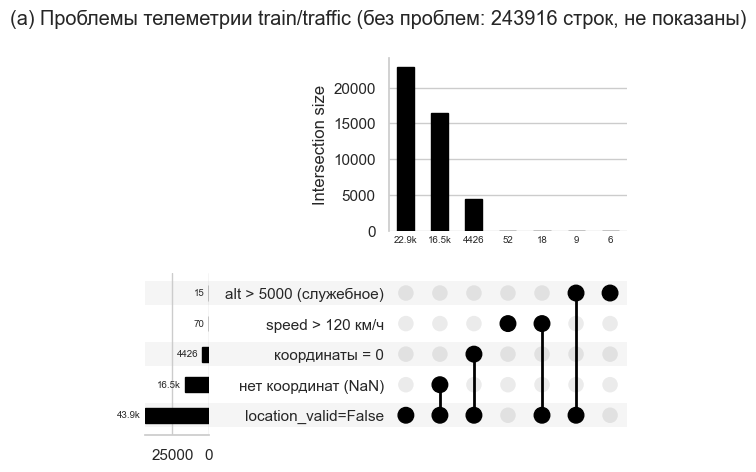

In [23]:
def draw_upset(data, suptitle, dots_opacity=0.08, gap=0.05, max_subsets=None):
    if max_subsets:
        data = data.groupby(level=list(range(data.index.nlevels))).sum().sort_values(ascending=False).head(max_subsets)
    fig = plt.figure(figsize=(10, 5.6))
    up = upsetplot.UpSet(data, subset_size="sum" if max_subsets else "count", sort_by="cardinality",
                         show_counts=False, other_dots_color=dots_opacity, shading_color=0.04)
    axes = up.plot(fig)
    a_int, a_tot = axes["intersections"], axes["totals"]
    p = a_int.get_position(); a_int.set_position([p.x0, p.y0 + gap, p.width, p.height - gap])
    fmt = lambda v: f"{v / 1000:.1f}k" if v >= 10000 else f"{int(round(v))}"
    for rect in a_int.patches:
        a_int.annotate(fmt(rect.get_height()), (rect.get_x() + rect.get_width() / 2, 0),
                       xytext=(0, -3), textcoords="offset points", ha="center", va="top", fontsize=7, annotation_clip=False)
    for rect in a_tot.patches:  # ось totals развёрнута: подпись у конца столбика, слева
        a_tot.annotate(fmt(rect.get_width()), (rect.get_width(), rect.get_y() + rect.get_height() / 2),
                       xytext=(-3, 0), textcoords="offset points", ha="right", va="center", fontsize=7, annotation_clip=False)
    fig.suptitle(suptitle); plt.show()

def draw_empty_upset(n, label, suptitle):
    fig, ax = plt.subplots(figsize=(4.6, 3.4))
    ax.bar([0], [n], width=0.45, color="black"); ax.set_xlim(-1, 1); ax.set_xticks([0])
    ax.set_xticklabels([f"{n}\n({label})"], fontsize=9); ax.set_ylabel("Intersection size")
    fig.suptitle(suptitle); plt.tight_layout(); plt.show()

def upset_from_bool(bool_df, title, empty_label="пусто", max_subsets=None):
    if not bool_df.any(axis=None):
        draw_empty_upset(len(bool_df), empty_label, title); return
    data = upsetplot.from_indicators(list(bool_df.columns), data=bool_df)
    if max_subsets:
        data = pd.Series(1, index=data.index)
    draw_upset(data, title, max_subsets=max_subsets)

tel_bad = anomaly_flags(traffic["train"]).drop(columns=["is_hist_data (досылка)"])
n_clean = int((~tel_bad.any(axis=1)).sum())
upset_from_bool(tel_bad[tel_bad.any(axis=1)],
                f"(а) Проблемы телеметрии train/traffic (без проблем: {n_clean} строк, не показаны)", max_subsets=12)

Проблемы с координатами почти всегда идут пакетом: `location_valid=False` и
NaN, либо `location_valid=False` и нули. То есть это не шум в отдельных полях,
а «пустые» навигационные ячейки NDTP, и выкидывать их надо целиком (что
`clean_traffic` и делает). Аномальная скорость и высота — отдельные редкие
пакеты.

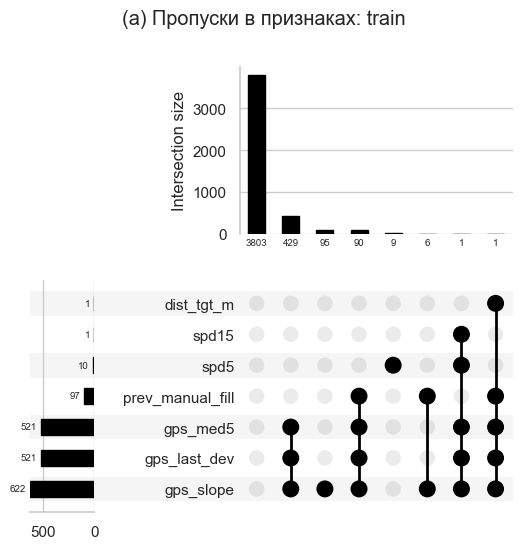

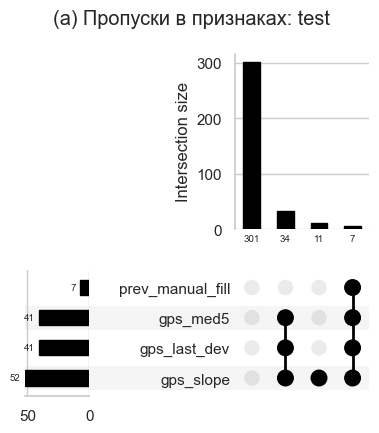

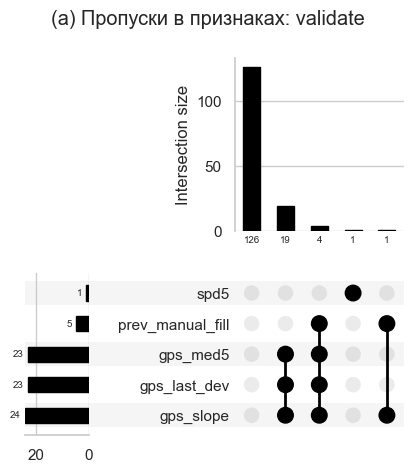

In [24]:
FEAT_MISS = ["gps_last_dev", "gps_med5", "gps_slope", "spd5", "spd15", "dist_tgt_m", "prev_manual_fill"]
for sp in ["train", "test", "validate"]:
    upset_from_bool(FE[sp][FEAT_MISS].isnull(), f"(а) Пропуски в признаках: {sp}", "пропусков нет")

Пропуски в признаках нужно проверить на совпадение распределений между
train и validate: если на validate GPS-истории нет у заметно большей доли
точек, модель должна уметь с этим жить. CatBoost обрабатывает NaN сам (как
отдельную ветку), поэтому **импутацию не делаем**. Урок Задания 1 — медиана
искажает связи — здесь особенно актуален.

**(б) Совпадения значений.** Для каждого признака отмечаем объекты, у которых
значение (с округлением до `MATCH_DECIMALS`) повторяется ещё хотя бы у одного
объекта. На непрерывных признаках повторы — это «застывшая» информация:
например, `cur_dev_s` не меняется между соседними T, пока ТС не прошло новую
остановку.

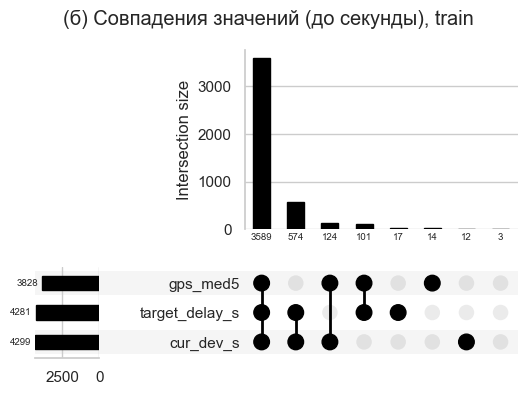

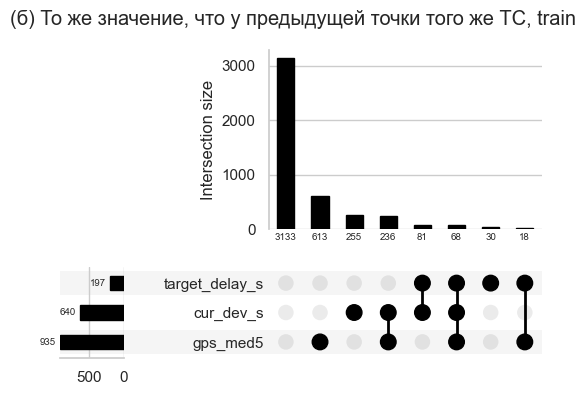

доля точек, где значение не изменилось с прошлой точки (T−5 мин):
cur_dev_s         0.144
gps_med5          0.211
target_delay_s    0.044


In [25]:
MATCH_DECIMALS = 0  # секунды; None — точное совпадение

def match_indicators(df, features, decimals=None):
    vals = df[features] if decimals is None else df[features].round(decimals)
    return pd.DataFrame({f: vals[f].notna() & vals[f].duplicated(keep=False) for f in features}, index=df.index)

def consecutive_repeat(df, features):
    d = df.sort_values(["tr_id", "sample_id"])
    return pd.DataFrame({f: d[f].notna() & (d.groupby("tr_id")[f].diff() == 0) for f in features}, index=d.index)

M_FEATS = ["cur_dev_s", "gps_med5", "target_delay_s"]
upset_from_bool(match_indicators(FE["train"], M_FEATS, MATCH_DECIMALS), "(б) Совпадения значений (до секунды), train")
upset_from_bool(consecutive_repeat(FE["train"], M_FEATS), "(б) То же значение, что у предыдущей точки того же ТС, train")
rep = consecutive_repeat(FE["train"], M_FEATS).mean().round(3)
print("доля точек, где значение не изменилось с прошлой точки (T−5 мин):"); print(rep.to_string())

Примерно в 14% точек `cur_dev_s` не изменилась за 5 минут: ТС стоит или
новая остановка ещё не зафиксирована. Точных совпадений по всему train
заметно больше, потому что клоны и разные ТС дают одинаковые круглые
значения. Значит, полезно знать, **как давно обновилась информация**
(`gps_age_s`, `last_fix_age_s`), и сглаживать историю медианой (`gps_med5`).

## [D] Графики, специфичные для задачи

### D.1 «Нитка графика»: задержка каждого реального ТС в течение дня

Та самая нитка графика из ТЗ, только в виде отклонения: по оси X плановое
время, по Y факт − план. Серые точки — остановки с `manual_fill=True`.

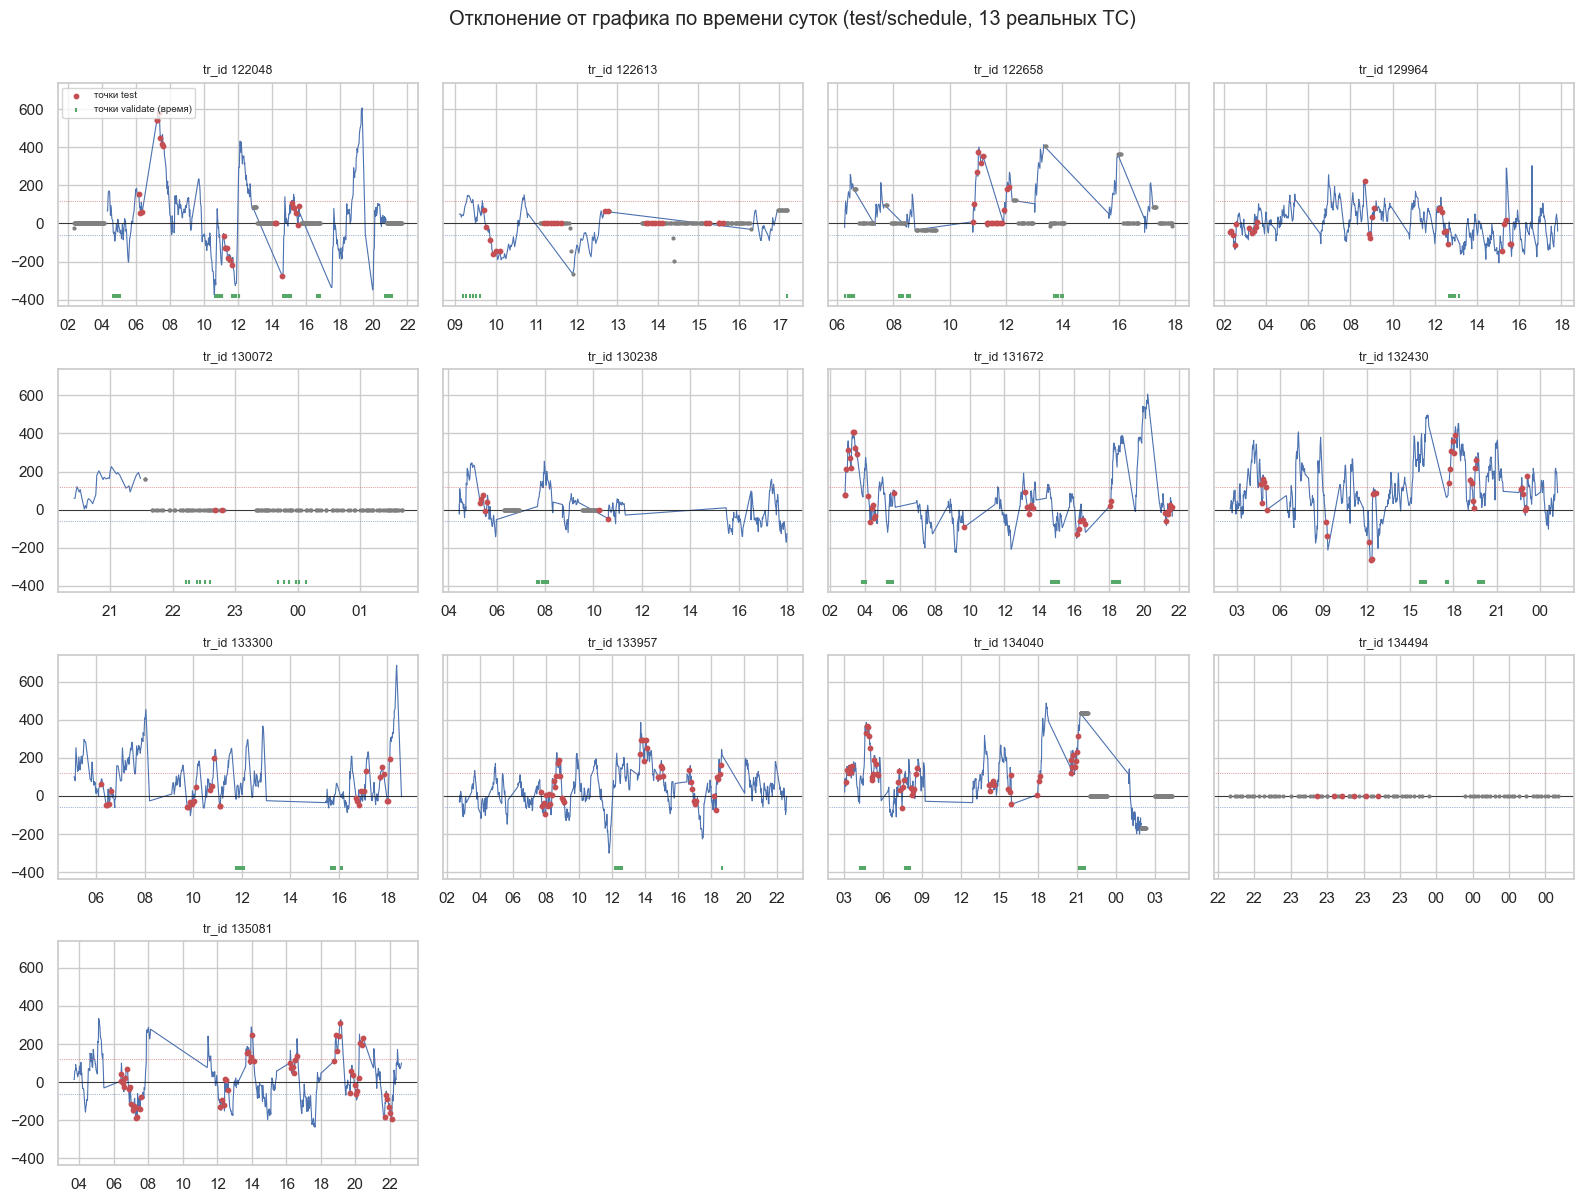

In [26]:
s_te = sched["test"].sort_values("time_begin")
fig, axes = plt.subplots(4, 4, figsize=(16, 12), sharey=True)
for ax, tid in zip(axes.flat, REAL_TR):
    g = s_te[s_te.tr_id == tid]
    a, m = g[~g.manual_fill], g[g.manual_fill]
    ax.plot(a.time_begin, a.delay_s, lw=0.8, color=pal[0])
    ax.scatter(m.time_begin, m.delay_s, s=4, color="grey", zorder=3)
    lt = points["test"][points["test"].tr_id == tid]; lv = points["validate"][points["validate"].tr_id == tid]
    ax.scatter(lt.target_time_begin, lt.target_delay_s, s=10, color=pal[3], zorder=4, label="точки test")
    ax.scatter(lv.target_time_begin, np.full(len(lv), -380), s=10, marker="|", color=pal[2], label="точки validate (время)")
    ax.axhline(0, color="k", lw=0.6); ax.axhline(120, color=pal[3], lw=0.5, ls=":"); ax.axhline(-60, color=pal[0], lw=0.5, ls=":")
    ax.set_title(f"tr_id {tid}", fontsize=9); ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%H"))
for ax in axes.flat[len(REAL_TR):]:
    ax.axis("off")
axes[0, 0].legend(fontsize=7, loc="upper left")
fig.suptitle("Отклонение от графика по времени суток (test/schedule, 13 реальных ТС)", y=1.0)
plt.tight_layout(); plt.show()

Задержка меняется плавно: у каждого ТС есть медленные «волны» опоздания,
которые копятся на протяжении рейса и сбрасываются на конечной. Отсюда
**инерционность**, на которой работает бейзлайн `cur_dev_s`, а ошибки бейзлайна
приходятся на моменты разворота волны: начало рейса (после конечной) и
быстрое накопление опоздания в пробках.

Ещё одна деталь: у `134494` **все** остановки, а у `130072` почти все, —
`manual_fill` (серые нули). Для таких ТС правильный прогноз — около 0, что бы
ни показывал GPS. Модель выучит это через `tgt_manual_fill`, `prev_manual_fill`
и `mf_share_next`.

### D.2 Как быстро «забывается» задержка: автокорреляция по остановкам

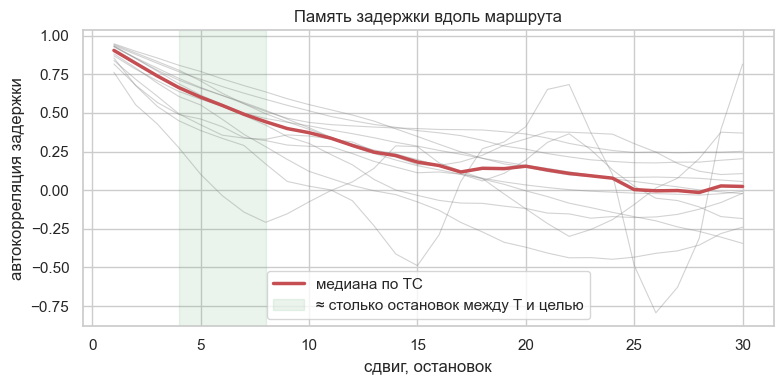

остановок между T и целевой (медиана): 6.0


In [27]:
lags = range(1, 31)
ac = {}
for tid in REAL_TR:
    g = s_te[(s_te.tr_id == tid) & (~s_te.manual_fill)].delay_s.reset_index(drop=True)
    ac[tid] = [g.autocorr(k) for k in lags]
ac = pd.DataFrame(ac, index=list(lags))
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ac.index, ac.values, color="grey", alpha=0.35, lw=0.8)
ax.plot(ac.index, ac.median(axis=1), color=pal[3], lw=2.5, label="медиана по ТС")
ax.axvspan(4, 8, color=pal[2], alpha=0.12, label="≈ столько остановок между T и целью")
ax.set_xlabel("сдвиг, остановок"); ax.set_ylabel("автокорреляция задержки"); ax.legend(); ax.set_title("Память задержки вдоль маршрута")
plt.tight_layout(); plt.show()
print("остановок между T и целевой (медиана):", FE["train"].n_stops_between.median())

На горизонте прогноза (между T и целью в среднем 6 остановок) автокорреляция ещё высокая, но
уже заметно ниже 1. «Текущая задержка» объясняет большую часть таргета, а
остаток — это то, как задержка **изменится** за ближайшие остановки. Поэтому
модели удобнее учить не сам таргет, а **приращение**
`target_delay_s − cur_dev_s` (см. раздел E).

### D.3 Карта: где копятся задержки

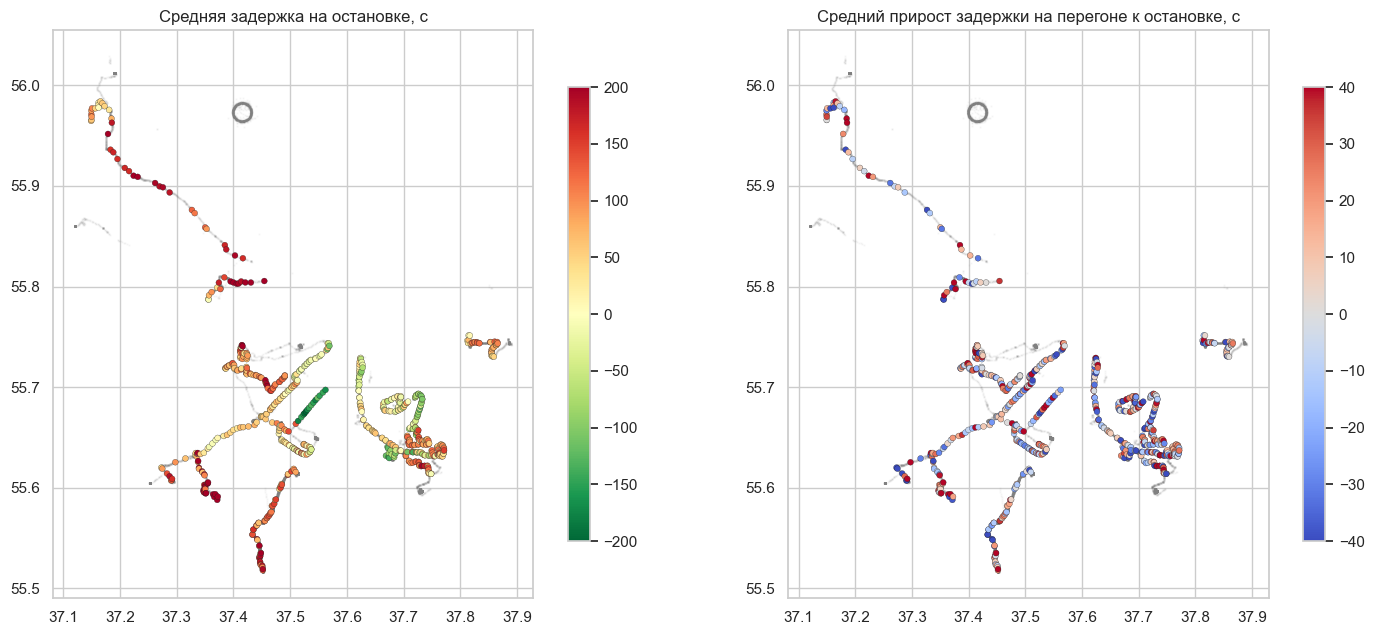

In [28]:
s_real_tr = sched["train"][sched["train"].tr_id.isin(REAL_TR) & ~sched["train"].manual_fill]
stop_stat = s_real_tr.groupby(["stop_lon", "stop_lat"]).delay_s.agg(["mean", "size"]).reset_index()
s_sorted = s_real_tr.sort_values(["tr_id", "time_begin"]).copy()
s_sorted["ddelay"] = s_sorted.groupby("tr_id").delay_s.diff()
grow = s_sorted.groupby(["stop_lon", "stop_lat"]).ddelay.mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, (df_, col, title, cmap, lim) in zip(axes, [
        (stop_stat, "mean", "Средняя задержка на остановке, с", "RdYlGn_r", 200),
        (grow, "ddelay", "Средний прирост задержки на перегоне к остановке, с", "coolwarm", 40)]):
    ax.scatter(cl_r.lon, cl_r.lat, s=0.5, alpha=0.05, c="grey")
    sc = ax.scatter(df_.stop_lon, df_.stop_lat, c=df_[col].clip(-lim, lim), cmap=cmap, s=18, vmin=-lim, vmax=lim, edgecolors="k", linewidths=0.2)
    plt.colorbar(sc, ax=ax, shrink=0.8); ax.set_title(title); ax.set_aspect(1 / np.cos(np.radians(55.7)))
plt.tight_layout(); plt.show()

Правая карта — прототип «цветовой индикации проблемных участков» для
дашборда. Перегоны, на которых задержка систематически **растёт**, — это
кандидаты в признак `segment_growth` (исторический средний прирост на
ближайших остановках до цели) и в объяснение причины для карточки инцидента.

### D.4 Где ошибается бейзлайн

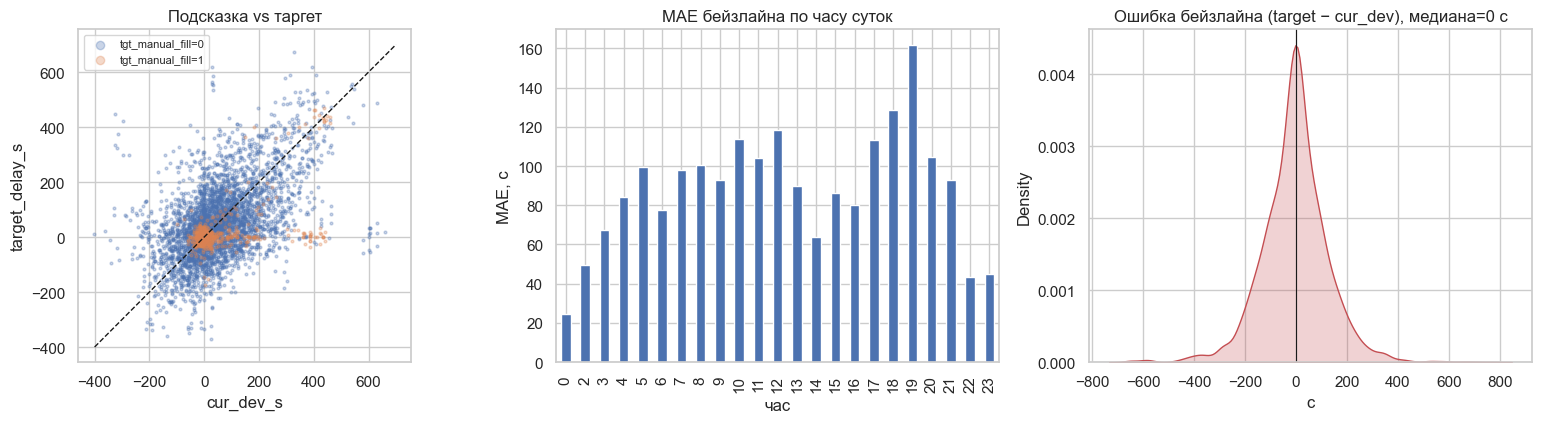

,n,MAE бейзлайна,MAE прогноза 0
tgt_manual_fill,,,
0,3721.0,101.8,110.2
1,713.0,47.5,29.4


In [29]:
L = FE["train"].copy()
L["base_err"] = L.target_delay_s - L.cur_dev_s
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for mf, c in [(0, pal[0]), (1, pal[1])]:
    g = L[L.tgt_manual_fill == mf]
    axes[0].scatter(g.cur_dev_s, g.target_delay_s, s=4, alpha=0.3, color=c, label=f"tgt_manual_fill={mf}")
axes[0].plot([-400, 700], [-400, 700], "k--", lw=1); axes[0].set_xlabel("cur_dev_s"); axes[0].set_ylabel("target_delay_s")
axes[0].legend(fontsize=8, markerscale=3); axes[0].set_title("Подсказка vs таргет"); axes[0].set_box_aspect(1)
L.groupby(L.hour.astype(int)).base_err.apply(lambda e: e.abs().mean()).plot.bar(ax=axes[1], color=pal[0])
axes[1].set_title("MAE бейзлайна по часу суток"); axes[1].set_xlabel("час"); axes[1].set_ylabel("MAE, с")
sns.kdeplot(L.base_err, ax=axes[2], fill=True, color=pal[3]); axes[2].axvline(0, color="k", lw=0.8)
axes[2].set_title(f"Ошибка бейзлайна (target − cur_dev), медиана={L.base_err.median():.0f} с"); axes[2].set_xlabel("с")
plt.tight_layout(); plt.show()
display(L.groupby("tgt_manual_fill").apply(lambda g: pd.Series({"n": len(g), "MAE бейзлайна": g.base_err.abs().mean(),
        "MAE прогноза 0": g.target_delay_s.abs().mean()})).round(1))

- При `tgt_manual_fill=1` прогноз «0» заметно лучше подсказки: таргет там
  искусственно нулевой.
- Медиана ошибки бейзлайна около 0, поэтому сдвиг на константу ничего не даёт
  (см. таблицу в E). Проблема не в смещении, а в **тяжёлых хвостах**: редкие
  точки, где задержка за 10 минут резко выросла или сбросилась, дают основную
  часть MAE. Их и должна ловить модель.
- Ошибка неравномерна по часам: утро и вечерний пик хуже. Час суток — полезный
  признак, но на одном дне с ним легко переобучиться (см. E).

### D.5 Реальные vs синтетические ТС

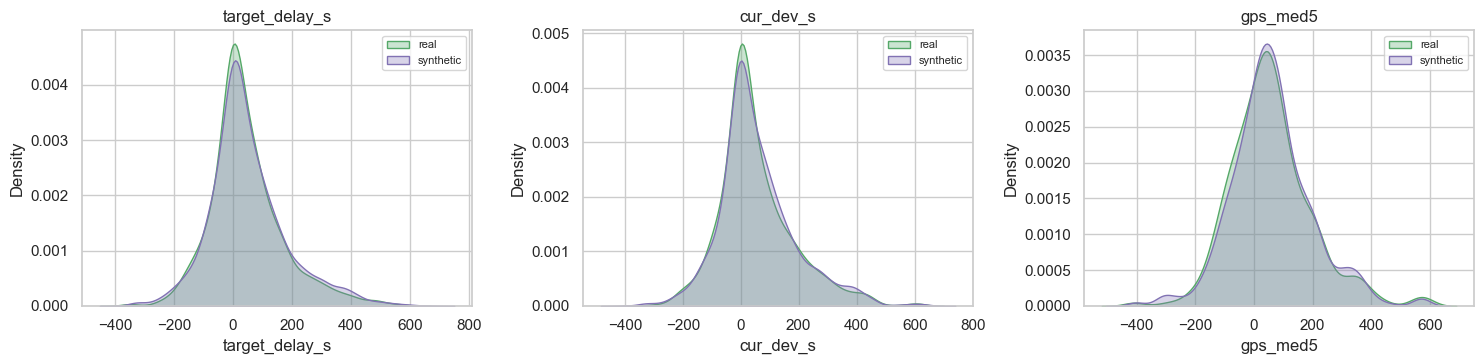

KS-тест real vs synthetic по target_delay_s: p = 0.0


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, col in zip(axes, ["target_delay_s", "cur_dev_s", "gps_med5"]):
    for kind, c in [("real", pal[2]), ("synthetic", pal[4])]:
        sns.kdeplot(FE["train"].loc[FE["train"].kind == kind, col].dropna(), ax=ax, color=c, fill=True, alpha=0.3, label=kind)
    ax.set_title(col); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("KS-тест real vs synthetic по target_delay_s: p =",
      round(spstats.ks_2samp(FE["train"].query("kind=='real'").target_delay_s, FE["train"].query("kind=='synthetic'").target_delay_s).pvalue, 4))

На глаз распределения близки, но KS-тест их различает (p ≈ 0: выборки
большие, и синтетика немного шире по хвостам). Синтетику можно использовать
как аугментацию, но решение «брать или не брать» стоит проверить абляцией.

Главное: клоны — это те же маршруты **в те же моменты времени**. Для 96% точек
test у клона того же ТС есть точка ровно с тем же `T`, и её таргет — зашумлённая
копия настоящего (r ≈ 0.64). Поэтому **при валидации клоны нужно держать в
одном фолде со своим реальным ТС** (группа = `SOURCE`).

## [E] Базовые модели и две схемы валидации

Считаем метрику так же, как платформа. `MAE_TARGET` нам не сообщили, но его
можно оценить: бейзлайн даёт score ≈ 0.40, значит
`MAE_TARGET ≈ mae_zero − (mae_zero − MAE_base) / 0.40`. Оценку делаем на test —
он из той же «вселенной», что validate.

**Две схемы валидации:**

- **Схема «как validate»:** обучаемся на train, проверяемся на test. Test и
  validate — это соседние моменты T тех же ТС в тот же день, так что эта схема
  лучше всего предсказывает скор на платформе.
- **Честная схема (LOVO):** leave-one-vehicle-out: откладываем реальное ТС
  **вместе с его клонами** и учимся на остальных. Она показывает, как модель
  будет работать на **новом** ТС или **другом** дне, то есть в продакшене и в
  демо на потоке эмулятора. Эту цифру стоит показать жюри.

In [31]:
def mae(y, p):
    return float(np.mean(np.abs(np.asarray(y) - np.asarray(p))))

te_ = FE["test"]
mae_zero_te, mae_base_te = mae(te_.target_delay_s, 0), mae(te_.target_delay_s, te_.cur_dev_s)
MAE_TARGET_EST = mae_zero_te - (mae_zero_te - mae_base_te) / 0.40

def score(y, p, mae_zero=None):
    mz = mae(y, 0) if mae_zero is None else mae_zero
    return float(np.clip((mz - mae(y, p)) / (mz - MAE_TARGET_EST), 0, 1))

print(f"test: mae_zero={mae_zero_te:.1f}  mae_baseline={mae_base_te:.1f}  -> оценка MAE_TARGET ≈ {MAE_TARGET_EST:.1f} с")
print("то есть score=1 примерно при MAE ≈", round(MAE_TARGET_EST, 1), "с; score 0.7 ≈",
      round(mae_zero_te - 0.7 * (mae_zero_te - MAE_TARGET_EST), 1), "с")

test: mae_zero=103.3  mae_baseline=93.4  -> оценка MAE_TARGET ≈ 78.4 с
то есть score=1 примерно при MAE ≈ 78.4 с; score 0.7 ≈ 85.9 с


In [32]:
def fit_cb(X, y, loss="RMSE", iters=1500, seed=0):
    return CatBoostRegressor(iterations=iters, learning_rate=0.03, depth=6, loss_function=loss,
                             random_seed=seed, verbose=0).fit(X, y)

FEATS_NO_TIME = [f for f in FEATS if f not in ("hour",)]
tr_ = FE["train"]
results = []

def add(name, pred_te):
    results.append(dict(модель=name, **{"MAE test": mae(te_.target_delay_s, pred_te), "score (оценка)": score(te_.target_delay_s, pred_te)}))

add("0 (нет задержки)", np.zeros(len(te_)))
add("cur_dev_s (бейзлайн платформы)", te_.cur_dev_s)
add("cur_dev_s + медианный сдвиг", te_.cur_dev_s + (tr_.target_delay_s - tr_.cur_dev_s).median())
add("правило: 0 если tgt_manual_fill, иначе cur_dev", np.where(te_.tgt_manual_fill == 1, 0, te_.cur_dev_s))

models = {}
for name, feats, loss, resid in [
        ("CatBoost RMSE, все признаки", FEATS, "RMSE", False),
        ("CatBoost MAE, все признаки", FEATS, "MAE", False),
        ("CatBoost RMSE на приращение (target − cur_dev)", FEATS, "RMSE", True),
        ("CatBoost RMSE, без hour", FEATS_NO_TIME, "RMSE", False)]:
    y = tr_.target_delay_s - tr_.cur_dev_s if resid else tr_.target_delay_s
    m = fit_cb(tr_[feats], y, loss)
    p = m.predict(te_[feats]) + (te_.cur_dev_s.values if resid else 0)
    models[name] = (m, feats, resid); add(name, p)

res_as_val = pd.DataFrame(results).set_index("модель").round(3)
res_as_val

,MAE test,score (оценка)
модель,,
0 (нет задержки),103.337,0.000
cur_dev_s (бейзлайн платформы),93.360,0.400
cur_dev_s + медианный сдвиг,93.360,0.400
"правило: 0 если tgt_manual_fill, иначе cur_dev",89.694,0.547
"CatBoost RMSE, все признаки",50.268,1.000
"CatBoost MAE, все признаки",56.790,1.000
CatBoost RMSE на приращение (target − cur_dev),51.318,1.000
"CatBoost RMSE, без hour",53.595,1.000


In [33]:
FE["train"]["source"] = FE["train"].tr_id.map(SOURCE)

def lovo(feats, loss="RMSE", resid=False, iters=600):
    errs, base = [], []
    for v in REAL_TR:
        a = FE["train"][FE["train"].source != v]
        b = FE["train"][FE["train"].tr_id == v]  # оцениваем только на реальном ТС
        if b.empty:
            continue
        y = a.target_delay_s - a.cur_dev_s if resid else a.target_delay_s
        m = fit_cb(a[feats], y, loss, iters)
        p = m.predict(b[feats]) + (b.cur_dev_s.values if resid else 0)
        errs += list(np.abs(b.target_delay_s - p)); base += list(np.abs(b.target_delay_s - b.cur_dev_s))
    return np.mean(errs), np.mean(base)

rows = []
for name, feats, loss, resid in [("все признаки", FEATS, "RMSE", False), ("без hour", FEATS_NO_TIME, "RMSE", False),
                                 ("приращение, без hour", FEATS_NO_TIME, "RMSE", True)]:
    m_, b_ = lovo(feats, loss, resid)
    rows.append({"модель (LOVO, клоны в одной группе)": name, "MAE": m_, "MAE бейзлайна": b_, "выигрыш, с": b_ - m_})
res_lovo = pd.DataFrame(rows).set_index("модель (LOVO, клоны в одной группе)").round(2)
res_lovo

,MAE,MAE бейзлайна,"выигрыш, с"
"модель (LOVO, клоны в одной группе)",,,
все признаки,78.75,86.84,8.09
без hour,77.74,86.84,9.09
"приращение, без hour",78.73,86.84,8.11


**Как читать две таблицы.**

- По схеме «как validate» CatBoost снижает MAE с 93 до ~50–54 с, то есть
  score упирается в 1. Причина — клоны: в train у того же маршрута в тот же
  момент T есть 2 синтетические точки с зашумлённой копией таргета, и модель
  фактически усредняет их. Правила это не нарушает (это обучающие данные, все
  признаки на момент T), и на validate тот же эффект сработает. Но такой скор
  **не переносится** на другой день или новое ТС.
- По честной схеме LOVO все варианты дают около 78 с против 87 у бейзлайна,
  то есть выигрыш ~9 с (≈10%). Это и есть реальное качество «на новом ТС», и
  именно его стоит показать жюри как честную оценку.
- Прямой таргет и приращение `target − cur_dev` на LOVO почти не различаются.
  Для сабмита берём приращение: оно безопаснее экстраполирует, потому что
  при непонятном входе модель откатывается к бейзлайну.

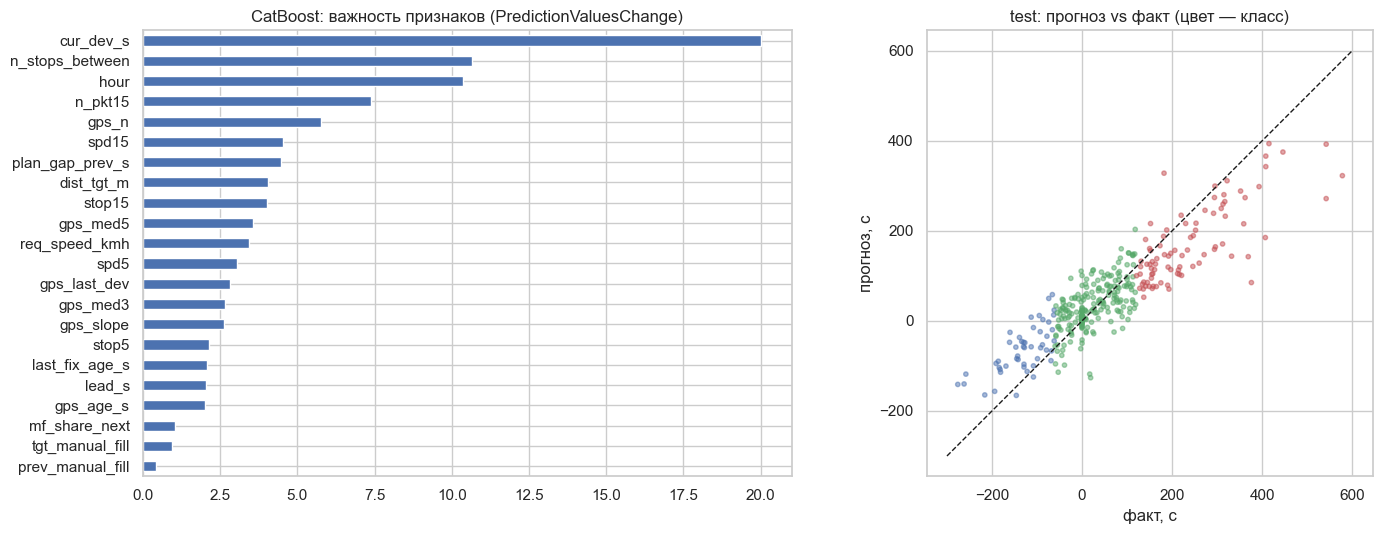

In [34]:
m_best, f_best, _ = models["CatBoost RMSE, все признаки"]
imp = pd.Series(m_best.get_feature_importance(), f_best).sort_values()
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
imp.plot.barh(ax=axes[0], color=pal[0]); axes[0].set_title("CatBoost: важность признаков (PredictionValuesChange)")
p = m_best.predict(te_[f_best])
axes[1].scatter(te_.target_delay_s, p, s=10, alpha=0.5, c=[CLASS_STYLE[c]["color"] for c in te_.target_class])
axes[1].plot([-300, 600], [-300, 600], "k--", lw=1); axes[1].set_box_aspect(1)
axes[1].set_xlabel("факт, с"); axes[1].set_ylabel("прогноз, с"); axes[1].set_title("test: прогноз vs факт (цвет — класс)")
plt.tight_layout(); plt.show()

## [F] Черновой сабмит

Обучаемся на train + test (разметка test легальна) и предсказываем validate.
Признаки validate строятся той же `build_features` из `validate/traffic.csv`,
`validate/schedule_plan.csv` и `validate/points.csv`, **без** фактов
расписания. Формат проверяем строго, как на платформе. Берём модель на
приращение и усредняем 5 сидов: так стабильнее.

In [35]:
full = pd.concat([FE["train"], FE["test"]], ignore_index=True)
va = FE["validate"]
preds = []
for seed in range(5):
    m = fit_cb(full[FEATS], full.target_delay_s - full.cur_dev_s, "RMSE", seed=seed)
    preds.append(m.predict(va[FEATS]) + va.cur_dev_s.values)
va_pred = pd.DataFrame({"sample_id": va.sample_id, "prediction": np.mean(preds, axis=0).round(1)})

sub = sample_sub[["sample_id"]].merge(va_pred, on="sample_id", how="left")
assert len(sub) == len(sample_sub) and sub.sample_id.is_unique and sub.prediction.notna().all()
sub.to_csv("submission_draft.csv", sep=";", index=False)
print("submission_draft.csv:", sub.shape, "| распределение прогноза:", sub.prediction.describe().round(1).to_dict())
sub.head()

submission_draft.csv: (151, 2) | распределение прогноза: {'count': 151.0, 'mean': 64.9, 'std': 126.6, 'min': -245.3, '25%': -5.6, '50%': 42.4, '75%': 103.6, 'max': 457.5}


,sample_id,prediction
0,131672_1767670500,1.7
1,131672_1767670800,90.0
2,131672_1767671100,151.7
3,131672_1767671400,217.6
4,134040_1767672000,61.6


## Итоговые выводы для ML-части

1. **Данные — один день, 13 реальных ТС** (+26 клонов в train). Train, test и
   validate — это перемешанные моменты T одних и тех же машин. Валидироваться
   нужно по двум схемам (train→test как прокси платформы, LOVO с клонами как
   честная оценка), и говорить об этом жюри открыто.
2. **В расписаниях train/test есть факты по целевым остановкам validate.** Это
   утечка из будущего. Не используем и сообщаем организаторам.
3. **Факты прибытия восстанавливаются из GPS** с медианной ошибкой около 3 с.
   Это ключевая идея: так мы получаем честную историю отклонений для validate
   и для живого NDTP-потока. Тот же модуль закрывает требование ТЗ к бэкенду
   («текущее отклонение, средняя скорость на сегменте, время простоя»).
4. **`manual_fill` целевой остановки** почти обнуляет таргет. Это легальный
   признак из планового расписания, и он заметно снижает MAE.
5. **Телеметрия грязная** (невалидные ячейки, (0,0), speed = 368,
   alt = 65505, разрывы на часы). `clean_traffic` нужно перенести в бэкенд
   один в один.
6. **CatBoost на табличных признаках обходит бейзлайн**: на test (прокси
   платформы) MAE ≈ 50 против 93, на честной LOVO ≈ 78 против 87. Разница
   между этими цифрами — вклад клонов «того же дня». Пропуски оставляем NaN,
   без импутации.
7. Честной LOVO-оценкой стоит проверять каждое решение по признакам, а
   train→test использовать только как прокси скора платформы.